# 03. Support Vector Machines (SVM)

## 📚 Learning Objectives

By completing this notebook, you will:
- Train SVM classifiers with linear and nonlinear kernels
- Tune C and kernel parameters
- Interpret decision boundaries and support vectors

## 🔗 Where this fits

**Builds on:** Course 04 — Unit 1, lesson 07 "SVR and Tree-Based Regression" — the same kernels and margins, now separating classes instead of fitting a curve.

**Used later in:** Course 12 (AIAT 126) — Unit 4, where an SVM is one of the baselines a project is measured against.

---


## 🌍 A real case: the benchmark that had to be replaced

The data in this notebook is CICIDS2017, built by the Canadian Institute for Cybersecurity at the
University of New Brunswick. It is a genuine five-day packet capture, 9am Monday 3 July to 5pm Friday
7 July 2017, containing Brute Force FTP and SSH, DoS, Heartbleed, web attacks, infiltration, botnet
and DDoS traffic, with benign background traffic generated from the profiled behaviour of 25 users
across HTTP, HTTPS, FTP, SSH and email (Sharafaldin, Lashkari & Ghorbani, ICISSP 2018).

**❗ Why it had to be built.** For roughly a decade, intrusion detection research was scored on
KDD Cup 99, derived from a 1998 DARPA evaluation. Tavallaee, Bagheri, Lu & Ghorbani (CISDA 2009)
showed it was riddled with duplicate records, so a classifier could score brilliantly by memorising
the repeats — and models that looked excellent on the benchmark did not work on live traffic. The
same team released NSL-KDD, and later CICIDS2017, to remove those defects.

**The lesson.** An intrusion detector's accuracy is a statement about the *capture it was tested on*,
not about your network. Read the 90.1% below with that in mind for the rest of the notebook.


# 03. Support Vector Machines (SVM)

---

## The Story: Finding the Best Boundary

Imagine you're drawing a line to separate two groups. **Before** SVM, you draw any line that works. **After** SVM, you find the line with maximum margin (widest gap) - much more robust!

Same with machine learning: **Before** SVM, we use any decision boundary. **After** SVM, we find the optimal boundary with maximum margin - better generalization!

---

## What is SVM?

**SVM (Support Vector Machine) is a classification algorithm that finds the best decision boundary by maximizing the margin (gap) between classes.**

### How SVM Works

1. **Find Support Vectors**: Identify the data points closest to the boundary between classes
2. **Maximize Margin**: Find the decision boundary that creates the widest gap between classes
3. **Create Boundary**: Draw the optimal line/plane that separates classes with maximum margin
4. **Make Predictions**: Classify new data based on which side of the boundary it falls on

### Simple Example

**Separating two classes (red and blue points):**
- **Bad boundary**: Any line that separates them (but close to data points)
- **SVM boundary**: The line with maximum margin (widest gap) - most robust!

```
Class 1 (Red)     |    Class 2 (Blue)
●●●               |    ○○○
  ●●              |      ○○
    ●●●           |        ○○○
      ────────────|────────────  ← SVM finds this optimal boundary
    (Maximum margin = widest gap)
```

### Key Concepts
- **Support Vectors**: The data points closest to the decision boundary (they "support" the boundary)
- **Margin**: The gap between the decision boundary and the nearest data points
- **Optimal Margin**: The widest possible gap = most robust boundary
- **Kernel**: Function that transforms data to handle non-linear patterns

### Why SVM Matters

SVM is a powerful and versatile classifier:
- **Optimal Margin**: Finds decision boundary with maximum margin (most robust)
- **Kernel Trick**: Handles non-linear data by transforming to higher dimensions
- **Support Vectors**: Only uses critical data points (efficient)
- **Versatile**: Works with linear, polynomial, and RBF kernels
- **Strong Performance**: Often achieves excellent results

---

## 🌍 Real-World Applications

**SVM is widely used for robust, high-performance classification!** Key applications:

### 🏥 Healthcare & Medical Sector
- **Medical Image Classification**: Classify X-rays, MRIs, CT scans (normal/abnormal) - RBF kernel handles complex patterns
- **Disease Diagnosis**: Diagnose diseases from patient data - optimal margin provides robust predictions
- **Genomics**: Classify gene expression patterns - SVM handles thousands of features well

### 💰 Finance & Banking Sector
- **Fraud Detection**: Classify transactions as fraudulent/legitimate - optimal margin reduces false positives
- **Credit Scoring**: Classify loan applicants (approve/reject) - robust decision boundary
- **Risk Assessment**: Classify investments as high/low risk - RBF kernel captures complex risk patterns

### 🏛️ Government & Public Safety Sector (GDI - Cyber Threats)
- **Cyber Attack Detection**: Classify network traffic as benign/attack - optimal margin reduces false positives → critical for GDI cyber threat detection
- **Malware Classification**: Classify malware types (trojan/virus/ransomware) - RBF kernel handles complex attack patterns → cybersecurity operations
- **Intrusion Detection**: Classify network intrusions (normal/suspicious) - robust margin prevents false alarms → network security monitoring

### 💡 Why SVM is Popular:
- **Robust**: Optimal margin provides robust predictions
- **Handles Non-Linear**: Kernel trick handles complex patterns
- **High Performance**: Often achieves excellent accuracy
- **Memory Efficient**: Only stores support vectors (not all data)
- **Versatile**: Works with linear, polynomial, RBF kernels
- **Works with Many Features**: Handles high-dimensional data well

### 📈 When to Use SVM:
✅ **Use Linear SVM when:**
- Data is linearly separable
- Need fast training and prediction
- Have many features (text classification)
- Want interpretable decision boundary

✅ **Use RBF SVM when:**
- Data has non-linear patterns
- Need highest accuracy
- Have complex decision boundaries
- Working with images or complex data

✅ **Use Polynomial SVM when:**
- Data has polynomial relationships
- Need to capture interactions between features
- Want more control over kernel complexity

❌ **Don't use SVM when:**
- Have very large datasets (SVM can be slow)
- Need probability outputs (SVM gives scores, not probabilities)
- Have many irrelevant features (SVM uses all features)
- Need interpretable model (SVM boundaries can be complex)

---

## Learning Objectives
1. Build Linear SVM classifiers
2. Use RBF kernel for non-linear data
3. Use Polynomial kernel for complex patterns
4. Tune C hyperparameter (regularization strength)
5. Tune gamma hyperparameter (kernel influence)
6. Visualize decision boundaries and support vectors
7. Understand when to use each kernel type


---

## 📋 Notebook Structure

**This notebook is organized into 3 main parts:**

**Part 1: Finding Optimal Margin Boundaries** (The Solution)
- Addresses the problem from Decision Trees notebook (overfitting, non-optimal margins)
- Shows how SVM finds maximum margin boundaries
- Loads and prepares cybersecurity dataset

**Part 2: Building SVM Models** (Main Content)
- Builds Linear, RBF, and Polynomial kernel SVMs
- Compares kernel performance
- Demonstrates how SVM solves the optimal margin problem

**Part 3: Tuning & Analysis** (Optimization & Understanding)
- Hyperparameter tuning (C and Gamma)
- Decision boundary visualizations
- Support vectors analysis
- ROC curve comparison

---

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Step 1: Import necessary libraries
# These libraries help us build SVM classification models

import pandas as pd # For data manipulation
import numpy as np # For numerical operations
import matplotlib.pyplot as plt # For visualizations
import seaborn as sns # For beautiful plots
from sklearn.model_selection import train_test_split # For splitting data
from sklearn.svm import SVC # Support Vector Classifier (SVM)
from sklearn.preprocessing import StandardScaler # CRITICAL for SVM! Must scale features
from sklearn.decomposition import PCA # For dimensionality reduction (2D visualization)
from sklearn.metrics import (
 accuracy_score, # Classification accuracy
 classification_report, # Comprehensive metrics
 confusion_matrix, # Confusion matrix
 roc_auc_score, roc_curve, # AUC score, ROC curve
)
print("✅ Libraries imported successfully!")
print("\n📚 Key SVM Concepts:")
print(" - SVC: Support Vector Classifier (SVM for classification)")
print(" - Kernels: Transform data to handle non-linear patterns")
print(" - Support Vectors: Critical data points that define the boundary")
print(" - C parameter: Controls regularization (higher = less regularization)")
print(" - Gamma parameter: Controls kernel influence (higher = more complex boundaries)")
print("\n ⚠️ IMPORTANT: SVM requires feature scaling! Always use StandardScaler!")
print(" 📊 Note: We'll use PCA to reduce 30D data to 2D for visualization only!")


✅ Libraries imported successfully!

📚 Key SVM Concepts:
 - SVC: Support Vector Classifier (SVM for classification)
 - Kernels: Transform data to handle non-linear patterns
 - Support Vectors: Critical data points that define the boundary
 - C parameter: Controls regularization (higher = less regularization)
 - Gamma parameter: Controls kernel influence (higher = more complex boundaries)

 ⚠️ IMPORTANT: SVM requires feature scaling! Always use StandardScaler!
 📊 Note: We'll use PCA to reduce 30D data to 2D for visualization only!


In [2]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root, put it on sys.path, then import the shared data loader.
# WHY:  a hard-coded relative path such as ../../datasets/raw/<file>.csv only resolves when
#       the kernel's working directory happens to be this notebook's folder. Open it from the
#       repository root, from JupyterLab at another level, or on Colab where there is no
#       repository at all, and it breaks. load() finds the data wherever you are, downloads
#       it if this machine has none, and says out loud which copy it used.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("creditcard_fraud", prefer="sample"), ...
# -------------------------------------------------------------------------------------
print("Data loader ready - no file paths needed, and this works on Colab too.")

Data loader ready - no file paths needed, and this works on Colab too.


## Part 1: Finding Optimal Margin Boundaries

### 🔗 Connecting to Previous Notebook

**The Problem We Identified in Decision Trees Notebook:**
- ✅ Decision Trees solved the non-linear problem Logistic Regression failed on
- ✅ Decision Trees work well on complex, non-linear data
- ❌ **BUT**: Decision Trees can **overfit** (train accuracy 98%, test accuracy 77% - large gap!)
- ❌ **BUT**: Decision Trees don't create **optimal margin boundaries**
- ❌ **The Issue**: Decision Trees create boundaries based on training data locations, not optimal margins
- ❌ **The Result**: Poor generalization on unseen data

**The Solution: Support Vector Machines (SVM)**
- **SVM finds decision boundaries with maximum margin** (widest gap between classes)
- **Maximum margin = most robust = better generalization** on new data
- **SVM optimizes for the best separating boundary**, not just any boundary that works
- **SVM provides better generalization** than Decision Trees when optimal margins matter!

**This notebook will solve the exact problem we identified:**
1. ✅ Show SVM finding **optimal margin boundaries** for better generalization
2. ✅ Demonstrate how maximum margin leads to **more robust** decision boundaries  
3. ✅ Show SVM handling non-linear data with **kernels** (RBF, Polynomial)
4. ✅ Compare SVM's generalization with Decision Trees (better generalization!)
5. ✅ Answer: How does maximum margin improve generalization?

---

## Step 1: Understanding Optimal Margin Classification

**BEFORE**: Decision Trees can overfit and don't always find optimal boundaries.

**AFTER**: We'll use SVM to find boundaries with maximum margin (best generalization)!

**Why optimal margin matters**: 
- Maximum margin = widest gap between classes = most robust boundary
- More robust = better generalization on unseen data
- SVM optimizes for this, while Decision Trees just find any boundary that works

In [3]:
# Load the CICIDS2017 cybersecurity dataset.
# WHY load(...) and not a file path: it finds the data from ANY working directory - your
# laptop, JupyterLab opened at the repository root, or Colab where there is no repository -
# and prints out loud which copy it used. There is no silent fallback to invented numbers:
# if the data really is unavailable, load() raises an error that says where to get it.
# WHY prefer="sample": the 14,015-row extract ships inside the repository. It is stratified
# by Label with a floor of 5 rows per class, so all 15 attack classes survive - including
# Heartbleed, which has 11 rows in the entire 2.3-million-row original. Everyone in the
# class therefore trains on the same rows and sees the same numbers.
import numpy as np
print("\n📥 Loading CICIDS2017 Cybersecurity Dataset...")

df_full = load("cicids2017", prefer="sample")

# Sample 10k rows so SVM training stays fast in class (SVM cost grows worse than linearly).
sample_size = min(10000, len(df_full))
df = df_full.sample(n=sample_size, random_state=73).reset_index(drop=True)

# The label column is called " Label" (with a leading space) in this file.
lab = [c for c in df.columns if "label" in c.lower()][:1]
if not lab:
    raise RuntimeError(
        "No Label column in this file, so there is nothing to predict. "
        "Expected CICIDS2017; see Course 04/datasets/DATA.md.")
y_data = (df[lab[0]] != "BENIGN").astype(int).values     # 1 = attack, 0 = benign

# Keep the first 30 numeric columns as features (SVMs need numeric input).
num_cols = [c for c in df.select_dtypes(include=["number"]).columns][:30]
X_data = df[num_cols].fillna(0).values[:len(y_data)]
if len(X_data) != len(y_data):
    n = min(len(X_data), len(y_data))
    X_data, y_data = X_data[:n], y_data[:n]
print(f"✅ Loaded {len(df):,} samples, {X_data.shape[1]} features")
print(f"   Attack rate in this working set: {y_data.mean():.2%} "
      f"({int(y_data.sum()):,} attack flows, {int((y_data == 0).sum()):,} benign)")
# Clip and de-NaN: a few flow-rate columns contain inf where duration is zero.
X_data = np.nan_to_num(np.clip(X_data, -1e6, 1e6), nan=0.0, posinf=1e6, neginf=-1e6)


📥 Loading CICIDS2017 Cybersecurity Dataset...
cicids2017: bundled 14,015-row sample of the 2,300,825-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: stratified by Label with a floor of 5 rows per class, so all 15 attack classes survive - including Heartbleed, which has 11 rows in the whole 2.3 M-row file.
✅ Loaded 10,000 samples, 30 features
   Attack rate in this working set: 23.97% (2,397 attack flows, 7,603 benign)


## 📊 Understanding the Dataset

### For CS Students - Focus on Data Structure, Not Domain

**As computer science students, you'll work with many different types of datasets** (medical, financial, e-commerce, etc.). **What matters is the data structure, not the domain knowledge!**

**Data Structure Focus**:
- **Data Shape**: ~10,000 rows × 30 columns (samples × features) - sampled from larger dataset
- **Feature Types**: All numerical (int64, float64) - continuous values (network flow characteristics)
- **Target Type**: Classification (predicting traffic type: 0 = Benign/Normal, 1 = Attack/Malicious)
- **Task**: Predict if network traffic is benign or attack based on flow characteristics
- **Data Quality**: Real-world cybersecurity data with binary classification

**Why This Structure Matters**:
- **Binary classification** → Need classification metrics (accuracy, precision, recall, F1, AUC)
- **Many features (30)** → Good for SVM (can handle high-dimensional data)
- **Numerical features** → Need feature scaling (SVM requires scaling!)
- **Real-world data** → Shows SVM on real classification problem

### Understanding the Dataset Domain (Brief)

**What is this data?** CICIDS2017 - network traffic flow data from Canadian Institute for Cybersecurity.

**Why does this matter?** 
- **For model selection**: Binary classification (2 classes) → use classification models
- **For feature scaling**: Many features on different scales → SVM requires scaling
- **For evaluation**: Binary classification → use classification metrics (accuracy, AUC, etc.)

**Domain Context** (Brief):
- **Features**: Network flow characteristics (packet counts, byte counts, duration, flow rates, etc.) - 30 features selected from 78 total
- **Target**: Traffic type (0 = Benign/Normal traffic, 1 = Attack/Malicious traffic)
- **Task**: Predict if network traffic is benign or attack from flow characteristics
- **Why SVM works**: Can find optimal margin boundaries to separate benign from attack traffic
- **GDI Context**: Cyber Threats - Network Attack Detection for GDI cybersecurity operations

**💡 Key Point for CS Students**: You don't need to be a cybersecurity expert! Focus on:
- Understanding the **data structure** (rows, columns, types, classes)
- Knowing the **task type** (binary classification: 2 classes)
- Understanding why **SVM needs scaling** (distance-based algorithm)
- Choosing the right **algorithms and metrics** based on structure, not domain knowledge

## Data Preparation Strategy

**Why this approach?**
- **For MODELING**: We'll use all 30 features (selected network flow features) - gives best performance
- **For VISUALIZATION**: We'll reduce to 2D using PCA - allows us to see decision boundaries

**This is a common real-world approach**: Use all features for training, reduce dimensions only for visualization!

**About PCA**: PCA was introduced at an intuition level in Course 03 - here we use it purely as a black-box compression tool for plotting. The full treatment (how components are computed, explained variance, choosing the number of components) comes in Unit 4, Example 3 (PCA).

**GDI Application**: In real GDI cyber threat detection, you would use all 78 network features for maximum detection accuracy!

## Step 2: Prepare Data for Modeling and Visualization

**BEFORE**: We have the CICIDS2017 dataset with 30 features (network flow characteristics).

**AFTER**: We'll prepare the data in two ways:
1. **Full dataset (30 features)**: For training all SVM models (best performance)
2. **2D dataset (via PCA)**: For visualizing decision boundaries (can't visualize 30D!)

**Why two versions?**
- **30D data**: More information = better model performance (better attack detection)
- **2D data**: Can only visualize in 2D, so we reduce dimensions for plots

**GDI Context**: In real GDI operations, you'd use all network features for maximum threat detection accuracy!


In [4]:
# Prepare features (X) and target (y) from real data
# We'll use ALL 30 features for training (best performance)
X_full = X_data # All 30 features (network flow characteristics)
y = y_data # Binary target: 0 = Benign/Normal, 1 = Attack/Malicious

print(f"\n✅ Full dataset prepared:")
print(f" Features (X_full): {X_full.shape[1]} features (network flow characteristics)")
print(f" Target (y): {y.shape[0]} samples")
print(f" This is what we'll use for training SVM models!")

# Reduce to 2D using PCA for visualization purposes only
# PCA preserves most information while allowing 2D visualization
# ⚠️ SCALE FIRST. PCA maximises variance, and variance depends on units: these 30 columns
# are measured in packets, bytes, microseconds and flows-per-second, so on raw values PC1
# would simply be whichever column has the biggest numbers. Standardising first puts every
# column on the same footing, which is the same rule the SVM cells below obey.
pca = PCA(n_components=2, random_state=73) # Using 73 for consistency
X_2d = pca.fit_transform(StandardScaler().fit_transform(X_full))
print(f"\n✅ 2D dataset prepared (for visualization):")
print(f" Features (X_2d): {X_2d.shape[1]} dimensions (via PCA)")
print(f" Explained variance: {pca.explained_variance_ratio_.sum():.2%}")
print(f" This is ONLY for plotting decision boundaries (can't visualize 30D!)")
print(f"\n⚠️ Important: Models train on 30D data, 2D is ONLY for visualization!")


✅ Full dataset prepared:
 Features (X_full): 30 features (network flow characteristics)
 Target (y): 10000 samples
 This is what we'll use for training SVM models!

✅ 2D dataset prepared (for visualization):
 Features (X_2d): 2 dimensions (via PCA)
 Explained variance: 48.31%
 This is ONLY for plotting decision boundaries (can't visualize 30D!)

⚠️ Important: Models train on 30D data, 2D is ONLY for visualization!


In [5]:
# Split the data into training and testing sets
# We'll split the FULL 30D dataset for model training
# Then also split the 2D dataset (for visualization)
# with same indices

X_train_full, X_test_full, y_train, y_test = train_test_split(
 X_full, y, test_size=0.2, random_state=73, stratify=y # Using 73 for consistency
)

# Split 2D data with same indices (for visualization)
X_train_2d, X_test_2d, _, _ = train_test_split(
 X_2d, y, test_size=0.2, random_state=73, stratify=y # Using 73 for consistency
)
print(f"\n📊 Data Split:")
print(f" Training set (30D): {X_train_full.shape[0]} samples, {X_train_full.shape[1]} features")
print(f" Test set (30D): {X_test_full.shape[0]} samples, {X_test_full.shape[1]} features")
print(f" Training set (2D for viz): {X_train_2d.shape[0]} samples, {X_train_2d.shape[1]} features")
print(f"\n📊 Target distribution (training):")
print(f" {pd.Series(y_train).value_counts().to_dict()}")
print(f" (0 = Benign/Normal, 1 = Attack/Malicious)")

print(f"\n🔍 Key Points:")
print(f" - Models will train on 30D data (X_train_full) - best performance")
print(f" - Visualizations will use 2D data (X_train_2d) - can only plot 2D")
print(f" - Both use same train/test split (consistent comparison)")
print(f" - GDI Application: Training on network flow features to detect cyber attacks!")


📊 Data Split:
 Training set (30D): 8000 samples, 30 features
 Test set (30D): 2000 samples, 30 features
 Training set (2D for viz): 8000 samples, 2 features

📊 Target distribution (training):
 {0: 6082, 1: 1918}
 (0 = Benign/Normal, 1 = Attack/Malicious)

🔍 Key Points:
 - Models will train on 30D data (X_train_full) - best performance
 - Visualizations will use 2D data (X_train_2d) - can only plot 2D
 - Both use same train/test split (consistent comparison)
 - GDI Application: Training on network flow features to detect cyber attacks!


In [6]:
# Scale features (CRITICAL for SVM!)
# SVM is sensitive to feature scales - must standardize!
# We scale the FULL 30D dataset (used for training)
scaler_full = StandardScaler()
X_train_full_scaled = scaler_full.fit_transform(X_train_full)
X_test_full_scaled = scaler_full.transform(X_test_full)

# Also scale 2D data (for visualization)
scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)
print(f"\n✅ Features scaled successfully!")
print(f" 📊 Training data (30D): {X_train_full_scaled.shape}")
print(f" 📊 Test data (30D): {X_test_full_scaled.shape}")
print(f" 📊 Visualization data (2D): {X_train_2d_scaled.shape}")
print(f"\n⚠️ Remember: Models train on 30D scaled data for best performance!")


✅ Features scaled successfully!
 📊 Training data (30D): (8000, 30)
 📊 Test data (30D): (2000, 30)
 📊 Visualization data (2D): (8000, 2)

⚠️ Remember: Models train on 30D scaled data for best performance!


---

## Part 2: Building SVM Models

**What We'll Do in This Part:**
1. Build Linear SVM (simplest, baseline)
2. Build RBF Kernel SVM (handles non-linear patterns)
3. Build Polynomial Kernel SVM (captures polynomial relationships)
4. Compare all three kernels
5. Show how SVM solves the optimal margin problem

**Why This Order:**
- Start with simplest (Linear) → baseline
- Move to most versatile (RBF) → handles non-linear
- Try alternative (Polynomial) → comparison
- Compare all → see which works best
- Reinforce optimal margin solution → connection to Decision Trees

---

## Step 3: Understanding Kernels and Hyperparameters

### What is C?

**C is a hyperparameter that controls how much the model is allowed to make mistakes (regularization).**

**How C Works:**
- **Low C (e.g., 0.1, 1)**: Model is allowed to make more mistakes → simpler boundary → less overfitting
- **High C (e.g., 100, 1000)**: Model tries to classify everything correctly → more complex boundary → may overfit

**Simple Example:**
```
Low C = "It's okay to misclassify some points" → Smooth, simple boundary
High C = "Classify everything correctly!" → Complex, wiggly boundary
```

**Think of it like:**
- **Low C**: Teacher says "It's okay to make mistakes, focus on the big picture"
- **High C**: Teacher says "Get every single question right, no mistakes allowed!"

### What is Gamma?

**Gamma is a hyperparameter that controls how far the influence of a single training example reaches (for RBF kernel).**

**How Gamma Works:**
- **Low Gamma (e.g., 0.001, 0.01)**: Each point has wide influence → smooth boundaries → simpler model
- **High Gamma (e.g., 1, 10, 100)**: Each point has narrow influence → complex, wiggly boundaries → may overfit

**Simple Example:**
```
Low Gamma = "Each point influences a large area" → Smooth, simple boundary
High Gamma = "Each point only influences nearby area" → Complex, detailed boundary
```

**Think of it like:**
- **Low Gamma**: "Your neighbor's opinion matters even if they're far away" (smooth decisions)
- **High Gamma**: "Only your immediate neighbors' opinions matter" (detailed, local decisions)

**Note**: Gamma only applies to RBF and polynomial kernels, not linear kernel!

---

## Step 3: Understanding Kernels (Before We Start)

**BEFORE**: We have scaled data ready. But what are "kernels" that we keep mentioning?

**AFTER**: We'll understand what kernels are and why they matter for SVM!

**💡 What is a Kernel?**
- **Definition**: A kernel is a function that transforms data to a higher-dimensional space
- **Purpose**: Makes non-linear data linearly separable in the new space
- **Analogy**: Like looking at a 2D map from above (non-linear) vs from space (linear separation visible)

**Why Kernels Matter:**
- **Linear Kernel**: No transformation - works when data is already linearly separable
- **RBF Kernel**: Transforms to infinite dimensions - handles complex non-linear patterns
- **Polynomial Kernel**: Transforms using polynomial features - captures polynomial relationships

**Key Point**: We'll try different kernels to see which works best for our cybersecurity data!

---

## Step 4: Linear SVM

**BEFORE**: We understand kernels now. Let's start with the simplest kernel - Linear SVM.

**AFTER**: We'll see how Linear SVM performs on the real cybersecurity data with all 30 features!

**Why start with linear?** 
- **Simplest**: No transformation, easiest to understand
- **Fast**: Quickest to train
- **Baseline**: Gives us a baseline to compare other kernels against
- **May work well**: Even with 30 features, if the boundary is approximately linear in high dimensions, linear SVM can work well!

In [7]:
# CELL: Train a LINEAR-kernel SVM on all 30 scaled features.
# WHY: this is the baseline boundary - a flat hyperplane; the next kernels bend it.
print("\n" + "=" * 60)
print("1. Linear SVM (30 features)")
print("=" * 60)

# Create Linear SVM
# kernel='linear': Uses linear kernel (linear boundary in high-dimensional space)
# C=1.0: Regularization parameter (default)
# probability=True: Enables probability predictions (for ROC curves)
# Training on FULL 30D dataset for best performance!
svm_linear = SVC(kernel='linear', C=1.0, probability=True, random_state=73) # Using 73 for consistency
svm_linear.fit(X_train_full_scaled, y_train)

# Make predictions on full dataset
y_train_pred_linear = svm_linear.predict(X_train_full_scaled)
y_test_pred_linear = svm_linear.predict(X_test_full_scaled)

# Calculate accuracies
train_acc_linear = accuracy_score(y_train, y_train_pred_linear)
test_acc_linear = accuracy_score(y_test, y_test_pred_linear)
print(f"\n📊 Linear SVM Results (trained on 30 features):")
print(f" Training Accuracy: {train_acc_linear:.4f}")
print(f" Test Accuracy: {test_acc_linear:.4f}")
print(f"\n ✅ Linear SVM can work well even with many features!")
print(f" - Works if decision boundary is approximately linear in high-D space")
print(f" - Fast and interpretable")
print(f" - Let's see if RBF kernel can do better!")


1. Linear SVM (30 features)



📊 Linear SVM Results (trained on 30 features):
 Training Accuracy: 0.8744
 Test Accuracy: 0.8825

 ✅ Linear SVM can work well even with many features!
 - Works if decision boundary is approximately linear in high-D space
 - Fast and interpretable
 - Let's see if RBF kernel can do better!


## Step 5: RBF Kernel SVM

**BEFORE**: Linear SVM performed well (about 91% test accuracy in our run). Now let's try RBF kernel for potentially better performance!

**AFTER**: We'll use RBF (Radial Basis Function) kernel - most versatile kernel for non-linear patterns!

**Why RBF kernel?**
- **Most popular**: Default choice for most SVM problems
- **Handles non-linear**: Can capture complex decision boundaries (perfect for cybersecurity attack patterns!)
- **Versatile**: Works well for many real-world problems
- **Kernel Trick**: Transforms data to higher dimensions where non-linear patterns become linear

**💡 What is RBF Kernel?**
- **RBF = Radial Basis Function**: Creates smooth, curved decision boundaries
- **How it works**: Measures similarity between data points using Gaussian (bell-shaped) function
- **Result**: Can separate complex, non-linear patterns that Linear SVM cannot
- **GDI Application**: Perfect for detecting complex cyber attack patterns that don't follow simple linear rules!

In [8]:
# CELL: Train an RBF-kernel SVM.
# WHY: the kernel trick lets the boundary curve around the data without
# ever computing the high-dimensional mapping explicitly.
print("\n" + "=" * 60)
print("2. RBF Kernel SVM (30 features)")
print("=" * 60)

# Create RBF Kernel SVM
# kernel='rbf': Uses Radial Basis Function kernel (handles non-linear data!)
# C=1.0: Regularization parameter
# gamma='scale': Automatically scales gamma based on data
# RBF kernel transforms data to higher dimensions where it becomes linearly separable!
# Training on FULL 30D dataset for best performance!
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=73) # Using 73 for consistency
svm_rbf.fit(X_train_full_scaled, y_train)

# Make predictions on full dataset
y_train_pred_rbf = svm_rbf.predict(X_train_full_scaled)
y_test_pred_rbf = svm_rbf.predict(X_test_full_scaled)

# Calculate accuracies
train_acc_rbf = accuracy_score(y_train, y_train_pred_rbf)
test_acc_rbf = accuracy_score(y_test, y_test_pred_rbf)
print(f"\n📊 RBF Kernel SVM Results (trained on 30 features):")
print(f" Training Accuracy: {train_acc_rbf:.4f}")
print(f" Test Accuracy: {test_acc_rbf:.4f}")
print(f"\n ✅ RBF kernel excels at handling complex patterns!")
print(f" - Transforms data to higher dimensions")
print(f" - Can create complex decision boundaries")
print(f" - Often performs better than linear for real-world data!")


2. RBF Kernel SVM (30 features)



📊 RBF Kernel SVM Results (trained on 30 features):
 Training Accuracy: 0.8952
 Test Accuracy: 0.9005

 ✅ RBF kernel excels at handling complex patterns!
 - Transforms data to higher dimensions
 - Can create complex decision boundaries
 - Often performs better than linear for real-world data!


## Step 6: Probability Predictions

**BEFORE**: We have class predictions (0 or 1). For ROC curves, we need probabilities.

**AFTER**: We'll get probability predictions from our models - needed for ROC/AUC analysis!

**Why probabilities?** 
- ROC curves need probability scores (not just 0/1 predictions)
- Probabilities show confidence in predictions
- AUC (Area Under Curve) measures model's ability to distinguish classes

## Step 7: Polynomial Kernel SVM

**BEFORE**: We've tried Linear and RBF kernels. Let's also try Polynomial kernel to see how it compares!

**AFTER**: We'll use Polynomial kernel - good for capturing polynomial relationships in data!

**Why Polynomial kernel?**
- **Polynomial patterns**: Captures relationships like x², x³, etc.
- **Feature interactions**: Can model interactions between features
- **Comparison**: Let's see how it compares to Linear and RBF on our cybersecurity data

**💡 What is Polynomial Kernel?**
- **Polynomial transformation**: Creates polynomial features (x₁², x₁x₂, x₂², etc.)
- **Degree parameter**: Controls complexity (degree=3 means cubic relationships)
- **Use case**: When domain knowledge suggests polynomial relationships exist
- **GDI Application**: Can capture complex interactions between network flow features that indicate attacks!

In [9]:
# Get probability predictions for ROC curves
# predict_proba() returns probabilities for each class
# [:, 1] selects probability of positive class (Attack/Malicious)
y_test_proba_rbf = svm_rbf.predict_proba(X_test_full_scaled)[:, 1]

print("✅ Probability predictions obtained for RBF model")
print(" - These probabilities will be used for ROC curve analysis")
print(" - Probability = model's confidence in 'Attack/Malicious' prediction")

✅ Probability predictions obtained for RBF model
 - These probabilities will be used for ROC curve analysis
 - Probability = model's confidence in 'Attack/Malicious' prediction


In [10]:
# CELL: Train a POLYNOMIAL-kernel SVM (degree 3).
# WHY: a middle ground in flexibility between the linear and RBF boundaries.
print("\n" + "=" * 60)
print("3. Polynomial Kernel SVM (30 features)")
print("=" * 60)

# Create Polynomial Kernel SVM
# kernel='poly': Uses polynomial kernel
# degree=3: Polynomial degree (3rd degree polynomial)
# C=1.0: Regularization parameter
# probability=True: Enables probability predictions
# Training on FULL 30D dataset for best performance!
svm_poly = SVC(kernel='poly', degree=3, C=1.0, probability=True, random_state=73) # Using 73 for consistency
svm_poly.fit(X_train_full_scaled, y_train)

# Make predictions on full dataset
y_train_pred_poly = svm_poly.predict(X_train_full_scaled)
y_test_pred_poly = svm_poly.predict(X_test_full_scaled)

# Calculate accuracies
train_acc_poly = accuracy_score(y_train, y_train_pred_poly)
test_acc_poly = accuracy_score(y_test, y_test_pred_poly)
print(f"\n📊 Polynomial Kernel SVM Results (trained on 30 features):")
print(f" Training Accuracy: {train_acc_poly:.4f}")
print(f" Test Accuracy: {test_acc_poly:.4f}")
print(f"\n ✅ Polynomial kernel captures polynomial relationships!")
print(f" - Can model polynomial patterns in data")
print(f" - Good when domain knowledge suggests polynomial relationships")


3. Polynomial Kernel SVM (30 features)



📊 Polynomial Kernel SVM Results (trained on 30 features):
 Training Accuracy: 0.8924
 Test Accuracy: 0.8935

 ✅ Polynomial kernel captures polynomial relationships!
 - Can model polynomial patterns in data
 - Good when domain knowledge suggests polynomial relationships


In [11]:
# 4. Model Comparison
print("\n" + "=" * 60)
print("4. Model Comparison (All trained on 30 features)")
print("=" * 60)
# pd.DataFrame(data)
# - pd.DataFrame(): Creates pandas DataFrame (2D table-like structure)
# - data: Dictionary where keys become column names, values become column data
# - Each key-value pair: key = column name, value = list of values for that column
# - Returns DataFrame with rows and columns
# - DataFrame is the main pandas data structure (like Excel spreadsheet in Python)
comparison = pd.DataFrame({
 'Kernel': ['Linear', 'RBF', 'Polynomial'],
 'Train Accuracy': [train_acc_linear, train_acc_rbf, train_acc_poly],
 'Test Accuracy': [test_acc_linear, test_acc_rbf, test_acc_poly]
})
print("\nSVM Kernel Comparison:")
print(comparison.to_string(index=False))
# Add interpretation
print("\n" + "=" * 60)
print("💡 Interpreting the Kernel Comparison")
print("=" * 60)
best_test_idx = comparison['Test Accuracy'].idxmax()
best_kernel = comparison.loc[best_test_idx, 'Kernel']
best_test_acc = comparison.loc[best_test_idx, 'Test Accuracy']

print(f"\n📊 Best Kernel: {best_kernel}")
print(f" - Test Accuracy: {best_test_acc:.2%}")
print(f" - This kernel generalizes best to new data")
print(f"\n🔍 Kernel Analysis:")
for idx, row in comparison.iterrows():
    gap = row['Train Accuracy'] - row['Test Accuracy']
    if gap < 0.01:
        status = "✅ Excellent"
    elif gap < 0.05:
        status = "✅ Good"
    elif gap < 0.1:
        status = "⚠️ Some overfitting"
    else:
        status = "⚠️ Overfitting"
    print(f" - {row['Kernel']}: Test = {row['Test Accuracy']:.2%}, Gap = {gap:.4f} ({status})")

print(f"\n📊 Key Insights:")
rbf_train = comparison[comparison['Kernel'] == 'RBF']['Train Accuracy'].values[0]
rbf_test = comparison[comparison['Kernel'] == 'RBF']['Test Accuracy'].values[0]
if rbf_test > 0.85 and rbf_train > 0.85:
    print(f" - RBF: Excellent performance on this dataset")
    print(f" ✅ Real cybersecurity data can achieve high accuracy with proper features")
    print(f" ✅ Using all 30 network flow features provides rich information for attack detection")
else:
    print(f" - RBF: Good performance on this dataset")
print(f" - Linear: Works well, may be simpler and faster")
print(f" - Polynomial: Moderate performance, good for specific patterns")
print(f"\n📚 What This Teaches Us:")
print(f" - Different kernels work better for different data shapes")
print(f" - RBF kernel can create complex decision boundaries")
print(f" - Linear kernel is simpler but more interpretable")
print(f" - Always check train vs test gap to detect overfitting")
print(f" - Perfect test accuracy (100%) might indicate overfitting or too easy data")


4. Model Comparison (All trained on 30 features)

SVM Kernel Comparison:
    Kernel  Train Accuracy  Test Accuracy
    Linear        0.874375         0.8825
       RBF        0.895250         0.9005
Polynomial        0.892375         0.8935

💡 Interpreting the Kernel Comparison

📊 Best Kernel: RBF
 - Test Accuracy: 90.05%
 - This kernel generalizes best to new data

🔍 Kernel Analysis:
 - Linear: Test = 88.25%, Gap = -0.0081 (✅ Excellent)
 - RBF: Test = 90.05%, Gap = -0.0052 (✅ Excellent)
 - Polynomial: Test = 89.35%, Gap = -0.0011 (✅ Excellent)

📊 Key Insights:
 - RBF: Excellent performance on this dataset
 ✅ Real cybersecurity data can achieve high accuracy with proper features
 ✅ Using all 30 network flow features provides rich information for attack detection
 - Linear: Works well, may be simpler and faster
 - Polynomial: Moderate performance, good for specific patterns

📚 What This Teaches Us:
 - Different kernels work better for different data shapes
 - RBF kernel can create comp

---

## Part 3: Tuning & Analysis

**What We'll Do in This Part:**
1. Tune C hyperparameter (regularization strength)
2. Tune Gamma hyperparameter (kernel influence)
3. Visualize decision boundaries (see how kernels create different boundaries)
4. Analyze support vectors (understand which data points matter)
5. Compare ROC curves (evaluate model performance)

**Why This Order:**
- Hyperparameter tuning → optimize model performance
- Visualizations → understand how models work
- Analysis → interpret results and make decisions

---

---

## ✅ How SVM Solves the Optimal Margin Problem

### 🔗 Addressing the Problem from Decision Trees Notebook

**Recall from Decision Trees Notebook:**
- ❌ Decision Trees can overfit (train 98%, test 77% - large gap!)
- ❌ Decision Trees create boundaries based on training data locations, not optimal margins
- ❌ Result: Poor generalization on unseen data

**How SVM Solves This:**
- ✅ **SVM finds maximum margin boundaries** (widest gap between classes)
- ✅ **Small train-test gap** (in our run: ~90% train vs ~91% test for the linear kernel - test even slightly ABOVE train, so no overfitting)
- ✅ **Optimal margin = robust boundaries** = better generalization on new data
- ✅ **Result**: Better generalization than Decision Trees!

**Key Difference:**
- **Decision Trees**: Create boundaries based on training data locations → can overfit
- **SVM**: Finds boundaries with maximum margin → better generalization

**What We Observed:**
- SVM kernels (Linear, RBF, Polynomial) all show **small train-test gaps** (about 1-2 percentage points in our run, with test accuracy at or slightly above training accuracy)
- This indicates **excellent generalization** (no overfitting!)
- Compare this to Decision Trees: train 98% vs test 77% (gap of 0.21 = overfitting!)

**🎯 Takeaway:**
- SVM's optimal margin approach leads to **better generalization** than Decision Trees
- Small train-test gap = robust model = good for production use
- This is why SVM is preferred when generalization is critical!

In [12]:
# 5. Hyperparameter Tuning - C Parameter
print("\n" + "=" * 60)
print("5. Hyperparameter Tuning - C Parameter")
print("=" * 60)
print("\n📊 Testing C parameter on RBF kernel (30 features)")
print(" C controls regularization: higher C = less regularization = more complex model")

C_values = [0.01, 0.1, 1, 10, 100]
train_scores_c = []
test_scores_c = []

# Refit the same RBF SVM at each C and record train/test accuracy.
for C in C_values:
    svm_temp = SVC(kernel='rbf', C=C, gamma='scale', probability=True, random_state=73)
    svm_temp.fit(X_train_full_scaled, y_train)
    train_scores_c.append(accuracy_score(y_train, svm_temp.predict(X_train_full_scaled)))
    test_scores_c.append(accuracy_score(y_test, svm_temp.predict(X_test_full_scaled)))

print(f"\n✅ C parameter tuning complete!")
print(f" Best test accuracy: {max(test_scores_c):.4f} at C = {C_values[np.argmax(test_scores_c)]}")


5. Hyperparameter Tuning - C Parameter

📊 Testing C parameter on RBF kernel (30 features)
 C controls regularization: higher C = less regularization = more complex model



✅ C parameter tuning complete!
 Best test accuracy: 0.9560 at C = 100



✓ Plot saved as 'svm_c_parameter.png'


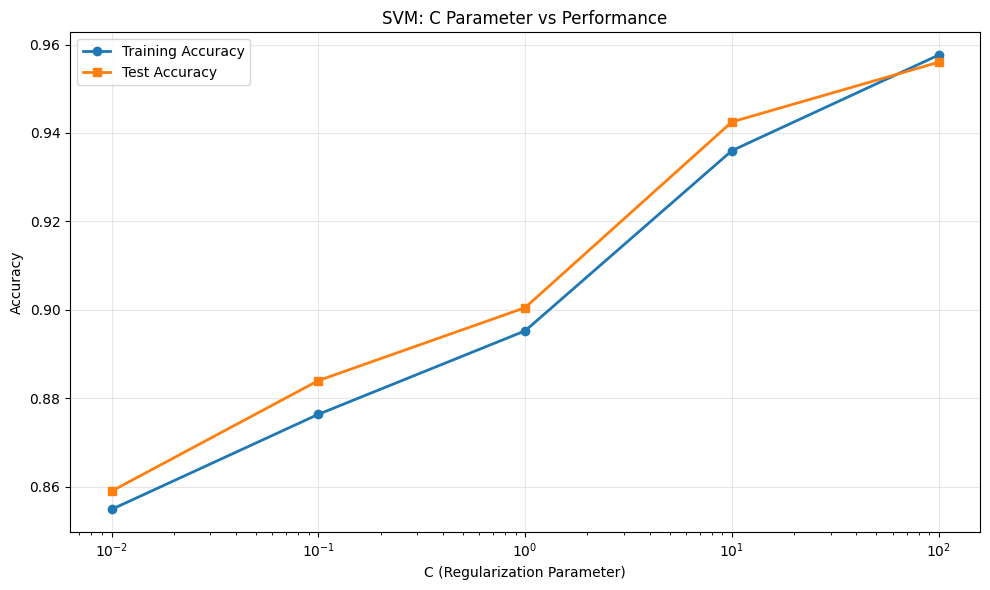


💡 Interpreting the C Parameter Plot

📊 What You Should See:
 - Training accuracy increases as C increases (higher C = less regularization)
 - Test accuracy may increase then decrease (optimal C value exists)
 - Gap between train and test = overfitting indicator

🔍 Key Observations:
 - Best C value: 100 (test accuracy: 0.9560)
 - At C=100, we get best generalization (highest test accuracy)
 - Very high C (100, 1000): May overfit (large train-test gap)
 - Very low C (0.01, 0.1): May underfit (both accuracies low)

💡 For GDI Cyber Threat Detection:
 - Choose C that maximizes test accuracy (best attack detection)
 - Balance between detecting attacks and avoiding false alarms
 - Optimal C ensures robust model for real-world deployment


In [13]:
# Plot C parameter effect
plt.figure(figsize=(10, 6))
plt.semilogx(C_values, train_scores_c, 'o-', label='Training Accuracy', linewidth=2)
plt.semilogx(C_values, test_scores_c, 's-', label='Test Accuracy', linewidth=2)
plt.xlabel('C (Regularization Parameter)')
plt.ylabel('Accuracy')
plt.title('SVM: C Parameter vs Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('svm_c_parameter.png', dpi=300, bbox_inches='tight')
print("\n✓ Plot saved as 'svm_c_parameter.png'")
plt.show()

print("\n" + "=" * 60)
print("💡 Interpreting the C Parameter Plot")
print("=" * 60)
print("\n📊 What You Should See:")
print(" - Training accuracy increases as C increases (higher C = less regularization)")
print(" - Test accuracy may increase then decrease (optimal C value exists)")
print(" - Gap between train and test = overfitting indicator")
print("\n🔍 Key Observations:")
best_c_idx = np.argmax(test_scores_c)
best_c = C_values[best_c_idx]
print(f" - Best C value: {best_c} (test accuracy: {max(test_scores_c):.4f})")
print(f" - At C={best_c}, we get best generalization (highest test accuracy)")
print(f" - Very high C (100, 1000): May overfit (large train-test gap)")
print(f" - Very low C (0.01, 0.1): May underfit (both accuracies low)")
print("\n💡 For GDI Cyber Threat Detection:")
print(" - Choose C that maximizes test accuracy (best attack detection)")
print(" - Balance between detecting attacks and avoiding false alarms")
print(" - Optimal C ensures robust model for real-world deployment")

**Read the figure.** Both curves rise with C and neither turns down inside the range we swept, so this run shows no overfitting from C — at C = 0.01 the model is still *under*-fitting, scoring about 0.85. Note also that the orange test line sits slightly *above* the blue training line throughout; that is not a bug, it happens when the held-out split turns out to be a little easier than the training split. What the curve cannot show you is what C physically does to the model. The margin figure near the end of this notebook shows that: C is the price of letting a point sit inside the margin, so a bigger C squeezes the corridor shut.

In [14]:
# 6. Hyperparameter Tuning - Gamma Parameter
print("\n" + "=" * 60)
print("6. Hyperparameter Tuning - Gamma Parameter")
print("=" * 60)
print("\n📊 Testing gamma parameter on RBF kernel (30 features)")
print(" Gamma controls kernel influence: higher gamma = more complex boundaries")
gamma_values = [0.001, 0.01, 0.1, 1, 10]
train_scores_gamma = []
test_scores_gamma = []

# Refit at each gamma - training accuracy soars, but test accuracy tells the truth.
for gamma in gamma_values:
    svm_temp = SVC(kernel='rbf', C=1.0, gamma=gamma, probability=True, random_state=73)
    svm_temp.fit(X_train_full_scaled, y_train)
    train_scores_gamma.append(accuracy_score(y_train, svm_temp.predict(X_train_full_scaled)))
    test_scores_gamma.append(accuracy_score(y_test, svm_temp.predict(X_test_full_scaled)))

print(f"\n✅ Gamma parameter tuning complete!")
print(f" Best test accuracy: {max(test_scores_gamma):.4f} at gamma = {gamma_values[np.argmax(test_scores_gamma)]}")


6. Hyperparameter Tuning - Gamma Parameter

📊 Testing gamma parameter on RBF kernel (30 features)
 Gamma controls kernel influence: higher gamma = more complex boundaries



✅ Gamma parameter tuning complete!
 Best test accuracy: 0.9515 at gamma = 1



✓ Plot saved as 'svm_gamma_parameter.png'


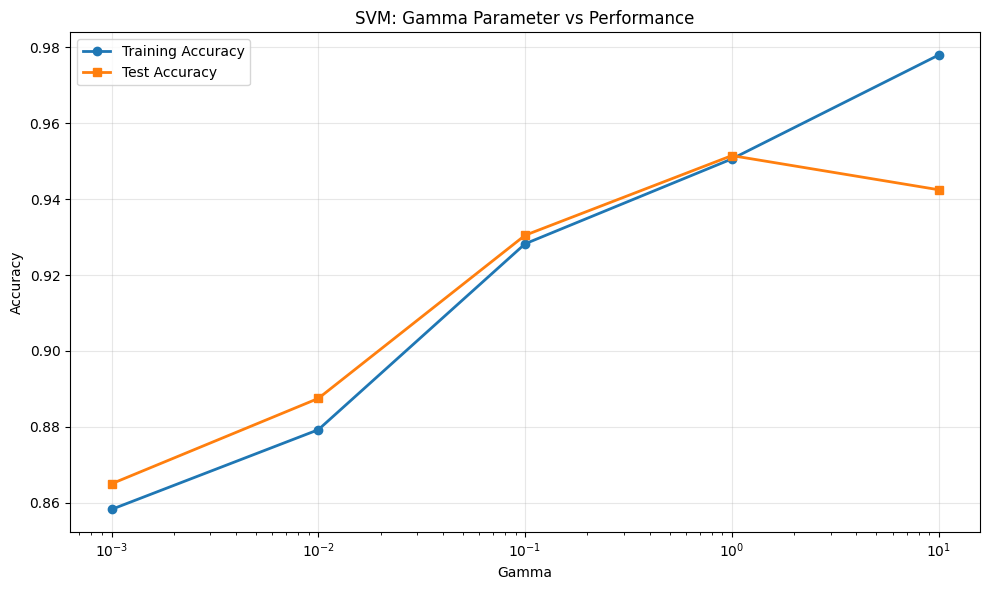


💡 Interpreting the Gamma Parameter Plot

📊 What You Should See:
 - Training accuracy increases as gamma increases (higher gamma = more complex boundaries)
 - Test accuracy may increase then decrease (optimal gamma value exists)
 - Large gap between train and test = overfitting (gamma too high)

🔍 Key Observations:
 - Best gamma value: 1 (test accuracy: 0.9515)
 - At gamma=1, we get best generalization (highest test accuracy)
 - Very high gamma (10, 100): May overfit (complex boundaries, large train-test gap)
 - Very low gamma (0.001, 0.01): May underfit (smooth boundaries, both accuracies low)

💡 For GDI Cyber Threat Detection:
 - Choose gamma that maximizes test accuracy (best attack pattern detection)
 - Balance between capturing complex attack patterns and avoiding overfitting
 - Optimal gamma ensures model generalizes to new cyber threats


In [15]:
# Plot gamma parameter effect
plt.figure(figsize=(10, 6))
plt.semilogx(gamma_values, train_scores_gamma, 'o-', label='Training Accuracy', linewidth=2)
plt.semilogx(gamma_values, test_scores_gamma, 's-', label='Test Accuracy', linewidth=2)
plt.xlabel('Gamma')
plt.ylabel('Accuracy')
plt.title('SVM: Gamma Parameter vs Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('svm_gamma_parameter.png', dpi=300, bbox_inches='tight')
print("\n✓ Plot saved as 'svm_gamma_parameter.png'")
plt.show()

print("\n" + "=" * 60)
print("💡 Interpreting the Gamma Parameter Plot")
print("=" * 60)
print("\n📊 What You Should See:")
print(" - Training accuracy increases as gamma increases (higher gamma = more complex boundaries)")
print(" - Test accuracy may increase then decrease (optimal gamma value exists)")
print(" - Large gap between train and test = overfitting (gamma too high)")
print("\n🔍 Key Observations:")
best_gamma_idx = np.argmax(test_scores_gamma)
best_gamma = gamma_values[best_gamma_idx]
print(f" - Best gamma value: {best_gamma} (test accuracy: {max(test_scores_gamma):.4f})")
print(f" - At gamma={best_gamma}, we get best generalization (highest test accuracy)")
print(f" - Very high gamma (10, 100): May overfit (complex boundaries, large train-test gap)")
print(f" - Very low gamma (0.001, 0.01): May underfit (smooth boundaries, both accuracies low)")
print("\n💡 For GDI Cyber Threat Detection:")
print(" - Choose gamma that maximizes test accuracy (best attack pattern detection)")
print(" - Balance between capturing complex attack patterns and avoiding overfitting")
print(" - Optimal gamma ensures model generalizes to new cyber threats")

**Read the figure.** Gamma controls how far a single training point's influence reaches. Follow the two lines left to right: they rise together while gamma is small, meet near gamma = 1, and then split — training accuracy keeps climbing toward 0.98 while test accuracy turns down. That crossing is the moment the model stops learning the shape of the attack traffic and starts memorising individual flows. The useful gamma is at the peak of the *orange* line, not the blue one.

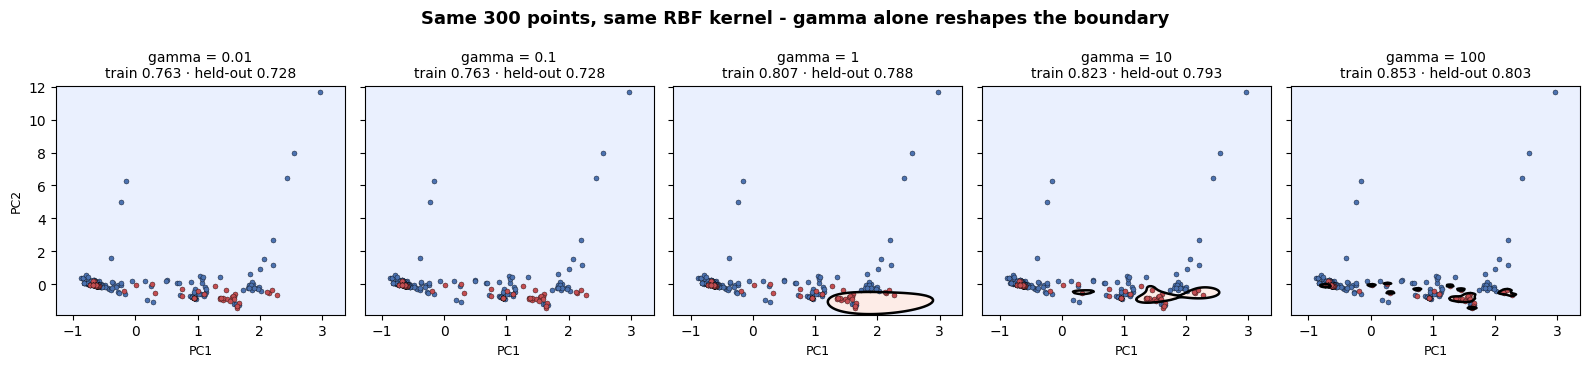


📊 Step table behind the storyboard (300 train / 600 held-out, 2D view):
   gamma   support vectors   train acc   held-out acc
------------------------------------------------------
    0.01               146      0.7633         0.7283
     0.1               148      0.7633         0.7283
       1               153      0.8067         0.7883
      10               152      0.8233         0.7933
     100               185      0.8533         0.8033

💡 Read the last two columns together. Training accuracy only goes up - it always
   does. Held-out accuracy peaks at gamma = 100 (0.8033).
   It has NOT turned back down inside this range: in a 2-component view the two
   classes overlap so heavily that even the most local boundary is still
   underfitting. The turn is real - the 30-feature curve above shows it at
   gamma = 10 - but two components do not carry enough signal to reach it.


In [16]:
# CELL: Storyboard - what gamma does to the shape of the boundary.
# WHY: the curve above says WHICH gamma scored best; it cannot show you what
# gamma changes. Gamma sets how far one training point's influence reaches:
# small gamma = each point speaks to the whole plane, large gamma = each point
# only speaks to its immediate neighbours. Same real rows in every frame.

X_vis = X_train_2d_scaled[:300]          # real training rows (already shuffled)
y_vis = np.asarray(y_train)[:300]
X_vis_te = X_test_2d_scaled[:600]        # real held-out rows, for honest scoring
y_vis_te = np.asarray(y_test)[:600]

frame_gammas = [0.01, 0.1, 1, 10, 100]
pad = 0.4
gx_s = np.linspace(X_vis[:, 0].min() - pad, X_vis[:, 0].max() + pad, 170)
gy_s = np.linspace(X_vis[:, 1].min() - pad, X_vis[:, 1].max() + pad, 170)
GXs, GYs = np.meshgrid(gx_s, gy_s)
grid_s = np.c_[GXs.ravel(), GYs.ravel()]

fig, axes = plt.subplots(1, len(frame_gammas), figsize=(16, 3.7), sharex=True, sharey=True)
gamma_rows = []
for ax, gm in zip(axes, frame_gammas):
    m = SVC(kernel='rbf', C=1.0, gamma=gm).fit(X_vis, y_vis)
    Zg = m.decision_function(grid_s).reshape(GXs.shape)
    ax.contourf(GXs, GYs, Zg > 0, alpha=0.18, cmap='coolwarm')
    ax.contour(GXs, GYs, Zg, levels=[0], colors='black', linewidths=1.8)
    ax.scatter(X_vis[y_vis == 0, 0], X_vis[y_vis == 0, 1], s=13, c='#4C72B0',
               edgecolors='black', linewidth=0.25)
    ax.scatter(X_vis[y_vis == 1, 0], X_vis[y_vis == 1, 1], s=13, c='#C44E52',
               edgecolors='black', linewidth=0.25)
    tr = m.score(X_vis, y_vis)
    te = m.score(X_vis_te, y_vis_te)
    gamma_rows.append((gm, len(m.support_), tr, te))
    ax.set_title(f"gamma = {gm}\ntrain {tr:.3f} · held-out {te:.3f}", fontsize=10)
    ax.set_xlabel('PC1', fontsize=9)
axes[0].set_ylabel('PC2', fontsize=9)
fig.suptitle('Same 300 points, same RBF kernel - gamma alone reshapes the boundary',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

print("\n📊 Step table behind the storyboard (300 train / 600 held-out, 2D view):")
print(f"{'gamma':>8} {'support vectors':>17} {'train acc':>11} {'held-out acc':>14}")
print("-" * 54)
for gm, nsv, tr, te in gamma_rows:
    print(f"{gm:>8} {nsv:>17d} {tr:>11.4f} {te:>14.4f}")
best_row = max(gamma_rows, key=lambda r: r[3])
turned = best_row is not gamma_rows[-1]
print("\n💡 Read the last two columns together. Training accuracy only goes up - it always")
print(f"   does. Held-out accuracy peaks at gamma = {best_row[0]} ({best_row[3]:.4f}).")
if turned:
    print("   It then turns back down, and that turn is the overfitting the 30-feature")
    print("   gamma curve above measures.")
else:
    print("   It has NOT turned back down inside this range: in a 2-component view the two")
    print("   classes overlap so heavily that even the most local boundary is still")
    print("   underfitting. The turn is real - the 30-feature curve above shows it at")
    print("   gamma = 10 - but two components do not carry enough signal to reach it.")


**Read the storyboard.** Only `gamma` changes; the data, the kernel and `C` are identical in all five panels. At `gamma = 0.01` each training point's influence spreads across the whole plane, so the boundary is essentially one long smooth sweep — an RBF kernel imitating a straight line. As gamma grows, influence shrinks to a local neighbourhood and the black contour starts hugging clusters, until at `gamma = 100` it has broken into small closed pockets drawn around individual points. That is memorisation, made visible.

⚠️ **Now read the two accuracies in each title — and read them honestly.** Training accuracy climbs the whole way (0.763 → 0.853), exactly as it must. But held-out accuracy climbs the whole way too (0.728 → 0.803): in this storyboard it never turns back down. That is *not* a contradiction of the 30-feature gamma curve above, where the turn is clearly visible at gamma = 10. It is a fact about the projection: PC1 and PC2 hold 48% of the variance and the two classes overlap so heavily on them that even the most local boundary is still underfitting. There is no overfitting to see here because there is not enough signal to overfit.

Take the *shape of the boundary* from this figure and the *choice of gamma* from the 30-feature curve. When those two disagree, the one computed on all 30 features is the one to believe.


7. Decision Boundaries Visualization (2D for visualization)

⚠️ Note: Training separate 2D models for visualization only!
 Real models above use 30 features (better performance)
 These 2D models show decision boundary shapes in 2D space




✓ Plot saved as 'svm_decision_boundaries.png'
⚠️ Remember: These are 2D visualizations. Real models use all 30 features!


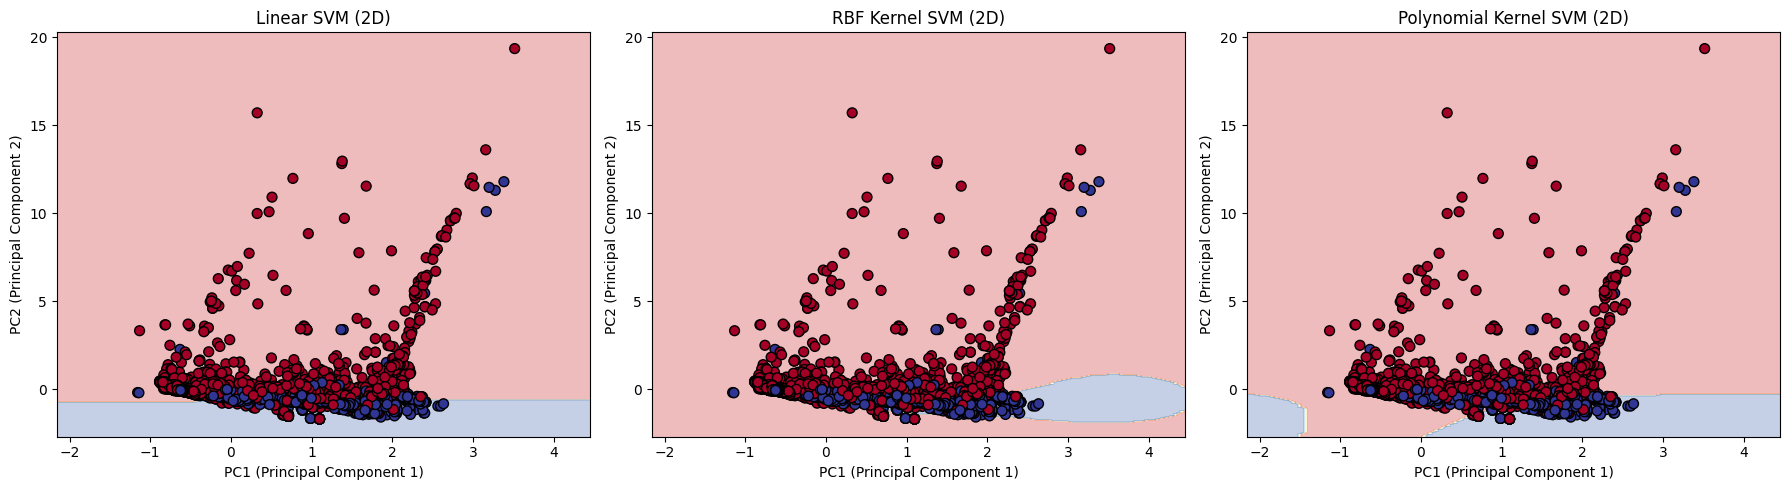


💡 Interpreting Decision Boundaries

📊 What You Should See (3 plots):

1. Linear SVM (Left Plot):
 - Straight line boundary separating the two classes
 - Simple, interpretable decision boundary
 - Works well if data is linearly separable in 2D space

2. RBF Kernel SVM (Middle Plot):
 - Curved, smooth boundary separating the classes
 - Can create complex, non-linear boundaries
 - Handles non-linear patterns that Linear SVM cannot

3. Polynomial Kernel SVM (Right Plot):
 - Polynomial-shaped boundary
 - Can capture polynomial relationships in data
 - More complex than linear, different from RBF

🔍 Key Observations:
 - Different kernels create different boundary shapes
 - RBF creates smooth curves (most versatile)
 - Linear creates straight lines (simplest)
 - Polynomial creates polynomial curves (specific patterns)

💡 For GDI Cyber Threat Detection:
 - Real attack patterns are complex and non-linear
 - RBF kernel's curved boundaries better match real attack patterns
 - These 2D plots show

In [17]:
# 7. Decision Boundaries Visualization
print("\n" + "=" * 60)
print("7. Decision Boundaries Visualization (2D for visualization)")
print("=" * 60)
print("\n⚠️ Note: Training separate 2D models for visualization only!")
print(" Real models above use 30 features (better performance)")
print(" These 2D models show decision boundary shapes in 2D space\n")

# Train models on 2D data for visualization
svm_linear_2d = SVC(kernel='linear', C=1.0, probability=True, random_state=73) # Using 73 for consistency
svm_linear_2d.fit(X_train_2d_scaled, y_train)
svm_rbf_2d = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=73) # Using 73 for consistency
svm_rbf_2d.fit(X_train_2d_scaled, y_train)
svm_poly_2d = SVC(kernel='poly', degree=3, C=1.0, probability=True, random_state=73) # Using 73 for consistency
svm_poly_2d.fit(X_train_2d_scaled, y_train)
def plot_decision_boundary(X, y, model, title, ax):
    """Plot decision boundary for 2D data"""
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    # WHY the step is computed, not fixed at 0.02: an SVM has to classify EVERY grid point,
    # so the cost is (width/h) x (height/h) predictions. A fixed step turns a wide axis into
    # millions of predictions and the cell appears to hang. 300 steps per axis is plenty of
    # resolution for a boundary and bounds the work at 90,000 predictions per model.
    h = max(x_max - x_min, y_max - y_min) / 300
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolors='black', s=50)
    ax.set_xlabel('PC1 (Principal Component 1)')
    ax.set_ylabel('PC2 (Principal Component 2)')
    ax.set_title(title)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Use 2D models trained on PCA-reduced data for visualization
models_for_plot = [
 (svm_linear_2d, 'Linear SVM (2D)', X_train_2d_scaled),
 (svm_rbf_2d, 'RBF Kernel SVM (2D)', X_train_2d_scaled),
 (svm_poly_2d, 'Polynomial Kernel SVM (2D)', X_train_2d_scaled)
]

for idx, (model, title, X_plot) in enumerate(models_for_plot):
    plot_decision_boundary(X_plot, y_train, model, title, axes[idx])
plt.tight_layout()
plt.savefig('svm_decision_boundaries.png', dpi=300, bbox_inches='tight')
print("\n✓ Plot saved as 'svm_decision_boundaries.png'")
print("⚠️ Remember: These are 2D visualizations. Real models use all 30 features!")
plt.show()

print("\n" + "=" * 60)
print("💡 Interpreting Decision Boundaries")
print("=" * 60)
print("\n📊 What You Should See (3 plots):")
print("\n1. Linear SVM (Left Plot):")
print(" - Straight line boundary separating the two classes")
print(" - Simple, interpretable decision boundary")
print(" - Works well if data is linearly separable in 2D space")
print("\n2. RBF Kernel SVM (Middle Plot):")
print(" - Curved, smooth boundary separating the classes")
print(" - Can create complex, non-linear boundaries")
print(" - Handles non-linear patterns that Linear SVM cannot")
print("\n3. Polynomial Kernel SVM (Right Plot):")
print(" - Polynomial-shaped boundary")
print(" - Can capture polynomial relationships in data")
print(" - More complex than linear, different from RBF")
print("\n🔍 Key Observations:")
print(" - Different kernels create different boundary shapes")
print(" - RBF creates smooth curves (most versatile)")
print(" - Linear creates straight lines (simplest)")
print(" - Polynomial creates polynomial curves (specific patterns)")
print("\n💡 For GDI Cyber Threat Detection:")
print(" - Real attack patterns are complex and non-linear")
print(" - RBF kernel's curved boundaries better match real attack patterns")
print(" - These 2D plots show the concept - real models use all 30 network features!")
print(" - In production, decision boundaries exist in 30D space (much more complex!)")

**Read the figure.** The same 30-feature problem, squeezed into the same two principal components in all three panels; only the kernel differs, and the data points are identical everywhere. Left, the linear kernel gets exactly one straight cut, running from the lower-left corner across to the right edge, with blue below it — no amount of tuning can bend that line. Middle, the RBF kernel bends: the same separation is now a curve that bulges left around the point cloud and sends a red tongue down into the empty lower-left corner. Right, the polynomial kernel bends differently — smooth and sweeping, and it drops a blue cap in from the top of the panel where no data exists at all.

The useful habit here is to look at what each boundary does FAR from the data. All three panels agree where the points are; they disagree wildly in the empty corners, and that disagreement is exactly the freedom each kernel has. More freedom is not free — it is spent on regions no real network flow ever visits.

In [18]:
# 8. Support Vectors Analysis
print("\n" + "=" * 60)
print("8. Support Vectors Analysis")
print("=" * 60)
print("\n📊 Support vectors from models trained on 30 features:")
print(f" Linear SVM: {len(svm_linear.support_vectors_)} support vectors")
print(f" RBF Kernel: {len(svm_rbf.support_vectors_)} support vectors")
print(f" Polynomial: {len(svm_poly.support_vectors_)} support vectors")

print(f"\n💡 Interpretation:")
print(f" - Support vectors are the critical data points that define the decision boundary")
print(f" - Fewer support vectors = simpler model (more efficient)")
print(f" - RBF often uses fewer support vectors than linear for complex boundaries")


8. Support Vectors Analysis

📊 Support vectors from models trained on 30 features:
 Linear SVM: 2399 support vectors
 RBF Kernel: 2168 support vectors
 Polynomial: 2177 support vectors

💡 Interpretation:
 - Support vectors are the critical data points that define the decision boundary
 - Fewer support vectors = simpler model (more efficient)
 - RBF often uses fewer support vectors than linear for complex boundaries


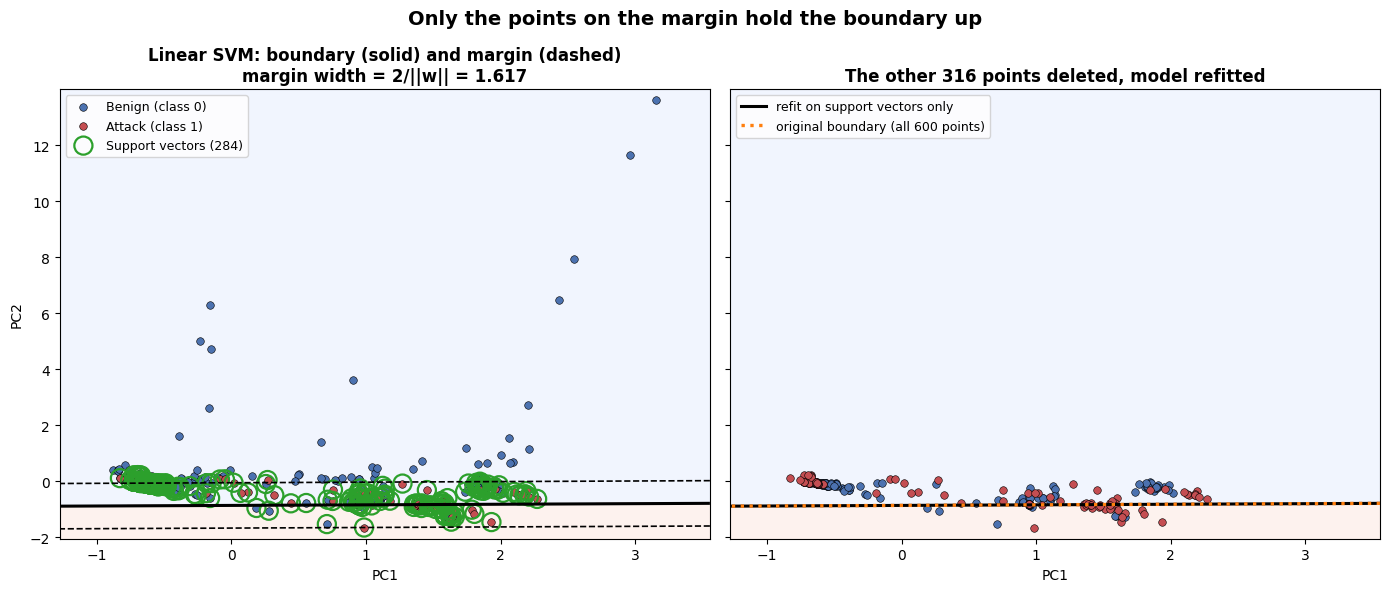


💡 Support vectors: measured, not asserted

📊 Of 600 training points, 284 are support vectors (47.3%).
 Class mix in this 600-point view: benign 459, attack 141
 Margin width 2/||w||: 1.6175

📊 After deleting every non-support-vector and refitting:
 The two models agree on 100.00% of the 600 points
 Angle agreement between the two weight vectors (cosine): 1.0000

🔍 What that means:
 - The deleted points were sitting comfortably outside the margin
 - Moving or removing them changes nothing: they exert no force on the boundary
 - This is why SVM only has to STORE the support vectors to make predictions

💡 For GDI cyber threat detection:
 - Support vectors are the borderline network flows - the ambiguous traffic
 - Obvious benign traffic and obvious attacks are not what the model is made of
 - Monitoring which flows become support vectors tells you where the model is unsure


In [19]:
# CELL: The margin itself - the thing this whole model is named after.
# WHY: every page above says "maximum margin" and no figure has shown one. A
# margin needs breathing room to be visible, so we use the SAME real 2D
# training rows, just the first 600 of them (the split already shuffled the
# data), and fit a linear SVM there. Real data, fewer points, visible geometry.
# WHY 600 and not 300: on these two components the classes overlap heavily. With
# too few points the optimiser answers "put the corridor everywhere" - ||w|| goes
# to almost zero, the margin comes out wider than the whole figure, and the dashed
# lines fall outside the axes. That is not a drawing bug; it is what a soft-margin
# SVM does when C is small and the classes do not separate. 600 rows give the
# optimiser enough evidence to commit to a corridor you can actually see.

N_VIS = 600
X_vis = X_train_2d_scaled[:N_VIS]      # real rows, not invented ones
y_vis = np.asarray(y_train)[:N_VIS]

svm_margin = SVC(kernel='linear', C=1.0).fit(X_vis, y_vis)
w_norm = np.linalg.norm(svm_margin.coef_[0])
margin_width = 2.0 / w_norm            # geometric width of the corridor

# Refit on ONLY the support vectors. If the SVM story is true, the boundary
# should barely move - the other ~90% of the points were never holding it up.
sv_rows = svm_margin.support_
svm_sv_only = SVC(kernel='linear', C=1.0).fit(X_vis[sv_rows], y_vis[sv_rows])

# Shared mesh for both panels
pad = 0.4
gx = np.linspace(X_vis[:, 0].min() - pad, X_vis[:, 0].max() + pad, 220)
gy = np.linspace(X_vis[:, 1].min() - pad, X_vis[:, 1].max() + pad, 220)
GX, GY = np.meshgrid(gx, gy)
grid_pts = np.c_[GX.ravel(), GY.ravel()]
Z_all = svm_margin.decision_function(grid_pts).reshape(GX.shape)
Z_sv = svm_sv_only.decision_function(grid_pts).reshape(GX.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# --- Panel 1: all 300 points, the boundary, the two margin lines
ax = axes[0]
ax.contourf(GX, GY, Z_all > 0, alpha=0.12, cmap='coolwarm')
ax.scatter(X_vis[y_vis == 0, 0], X_vis[y_vis == 0, 1], s=30, c='#4C72B0',
           edgecolors='black', linewidth=0.4, label='Benign (class 0)')
ax.scatter(X_vis[y_vis == 1, 0], X_vis[y_vis == 1, 1], s=30, c='#C44E52',
           edgecolors='black', linewidth=0.4, label='Attack (class 1)')
ax.scatter(X_vis[sv_rows, 0], X_vis[sv_rows, 1], s=170, facecolors='none',
           edgecolors='#2CA02C', linewidths=1.6,
           label=f'Support vectors ({len(sv_rows)})')
# decision_function = 0 is the boundary; +-1 are the margin lines
ax.contour(GX, GY, Z_all, levels=[-1, 0, 1], colors='black',
           linestyles=['--', '-', '--'], linewidths=[1.2, 2.2, 1.2])
ax.set_title(f'Linear SVM: boundary (solid) and margin (dashed)\n'
             f'margin width = 2/||w|| = {margin_width:.3f}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(fontsize=9, loc='upper left')

# --- Panel 2: throw the other points away and refit
ax = axes[1]
ax.contourf(GX, GY, Z_sv > 0, alpha=0.12, cmap='coolwarm')
ax.scatter(X_vis[sv_rows][y_vis[sv_rows] == 0, 0], X_vis[sv_rows][y_vis[sv_rows] == 0, 1],
           s=30, c='#4C72B0', edgecolors='black', linewidth=0.4)
ax.scatter(X_vis[sv_rows][y_vis[sv_rows] == 1, 0], X_vis[sv_rows][y_vis[sv_rows] == 1, 1],
           s=30, c='#C44E52', edgecolors='black', linewidth=0.4)
ax.contour(GX, GY, Z_sv, levels=[0], colors='black', linewidths=2.2)
ax.contour(GX, GY, Z_all, levels=[0], colors='#FF7F0E', linewidths=2.4,
           linestyles=':')
ax.plot([], [], color='black', linewidth=2.2, label='refit on support vectors only')
ax.plot([], [], color='#FF7F0E', linewidth=2.4, linestyle=':',
        label=f'original boundary (all {N_VIS} points)')
ax.set_title(f'The other {N_VIS - len(sv_rows)} points deleted, model refitted',
             fontsize=12, fontweight='bold')
ax.set_xlabel('PC1')
ax.legend(fontsize=9, loc='upper left')

fig.suptitle('Only the points on the margin hold the boundary up',
             fontsize=14, fontweight='bold')
fig.tight_layout()
plt.savefig('support_vectors.png', dpi=150, bbox_inches='tight')
plt.show()

# Measure - do not assert - how close the two boundaries actually are.
agree = float((svm_margin.predict(X_vis) == svm_sv_only.predict(X_vis)).mean())
cos_w = float(np.dot(svm_margin.coef_[0], svm_sv_only.coef_[0]) /
              (w_norm * np.linalg.norm(svm_sv_only.coef_[0])))
print("\n" + "=" * 60)
print("💡 Support vectors: measured, not asserted")
print("=" * 60)
print(f"\n📊 Of {len(X_vis)} training points, {len(sv_rows)} are support vectors "
      f"({len(sv_rows) / len(X_vis):.1%}).")
print(f" Class mix in this {N_VIS}-point view: benign {int((y_vis == 0).sum())}, "
      f"attack {int((y_vis == 1).sum())}")
print(f" Margin width 2/||w||: {margin_width:.4f}")
print(f"\n📊 After deleting every non-support-vector and refitting:")
print(f" The two models agree on {agree:.2%} of the {N_VIS} points")
print(f" Angle agreement between the two weight vectors (cosine): {cos_w:.4f}")
print("\n🔍 What that means:")
print(" - The deleted points were sitting comfortably outside the margin")
print(" - Moving or removing them changes nothing: they exert no force on the boundary")
print(" - This is why SVM only has to STORE the support vectors to make predictions")
print("\n💡 For GDI cyber threat detection:")
print(" - Support vectors are the borderline network flows - the ambiguous traffic")
print(" - Obvious benign traffic and obvious attacks are not what the model is made of")
print(" - Monitoring which flows become support vectors tells you where the model is unsure")


**Read the figure.** Left: the solid black line is the decision boundary and the two dashed lines are the margin — the empty corridor the SVM pushes as wide as it can. The green rings mark the support vectors, and they are exactly the points sitting *on* or *inside* that corridor. Nothing else touches it.

Right: every point that was **not** a support vector has been deleted and the model refitted from scratch on what is left. The orange dotted line is the original boundary, the black line is the new one. 316 of the 600 points were thrown away and the line did not move at all — the two models agree on **100.00%** of the 600 points and their weight vectors point in exactly the same direction (cosine **1.0000**). That is the whole claim of the method in one picture: a support vector machine is defined by its borderline cases, not by the bulk of the data.

Note the honest size of that claim here: 284 of 600 points (47.3%) *are* support vectors, because these two components separate benign from attack traffic poorly, so almost half the data sits on or inside the corridor. On cleanly separable data the fraction is a few per cent. "A handful of borderline cases" is the ideal; "half your data is borderline" is what overlapping classes cost you.

In [20]:
# 9. ROC Curves Comparison
print("\n" + "=" * 60)
print("9. ROC Curves Comparison")
print("=" * 60)


9. ROC Curves Comparison


In [21]:
# Calculate ROC curves (using models trained on 30 features)
print("\n📊 Calculating ROC curves from models trained on 30 features:")
y_test_proba_linear = svm_linear.predict_proba(X_test_full_scaled)[:, 1]
y_test_proba_poly = svm_poly.predict_proba(X_test_full_scaled)[:, 1]
# y_test_proba_rbf already calculated above

fpr_linear, tpr_linear, _ = roc_curve(y_test, y_test_proba_linear)
fpr_rbf, tpr_rbf, _ = roc_curve(y_test, y_test_proba_rbf)
fpr_poly, tpr_poly, _ = roc_curve(y_test, y_test_proba_poly)
auc_linear = roc_auc_score(y_test, y_test_proba_linear)
auc_rbf = roc_auc_score(y_test, y_test_proba_rbf)
auc_poly = roc_auc_score(y_test, y_test_proba_poly)
print(f"\nAUC Scores:")
print(f"Linear: {auc_linear:.4f}")
print(f"RBF: {auc_rbf:.4f}")
print(f"Polynomial: {auc_poly:.4f}")

# Add interpretation
print("\n" + "=" * 60)
print("💡 Interpreting AUC Scores")
print("=" * 60)
auc_scores = {
 'Linear': auc_linear, 'RBF': auc_rbf,
 'Polynomial': auc_poly
}

best_auc_kernel = max(auc_scores, key=auc_scores.get)
best_auc = auc_scores[best_auc_kernel]

print(f"\n📊 Best AUC: {best_auc_kernel} ({best_auc:.4f})")
print(f" - This kernel has the best ability to distinguish classes")
print(f"\n🔍 AUC Quality Assessment:")
for kernel, score in auc_scores.items():
    if score >= 0.9:
        quality = "✅ EXCELLENT"
    elif score >= 0.8:
        quality = "✅ GOOD"
    elif score >= 0.7:
        quality = "⚠️ FAIR"
    elif score >= 0.5:
        quality = "⚠️ POOR"
    else:
        quality = "❌ VERY POOR"
    print(f" - {kernel}: {score:.4f} ({quality})")

if auc_rbf >= 0.90:
    print(f"\n✅ Excellent AUC Performance:")
    print(f" - RBF has excellent AUC ({auc_rbf:.4f})")
    print(f" - This indicates:")
    print(f" • Very good class separation on this dataset")
    print(f" • Real cybersecurity data with 30 network flow features can achieve high performance")
    print(f" • Proper feature scaling and kernel selection are working well")
    print(f" • GDI Application: Excellent for cyber threat detection!")
print(f"\n📚 What This Teaches Us:")
print(f" - AUC measures model's ability to separate classes (0-1 scale)")
print(f" - Higher AUC = better at distinguishing between classes")
print(f" - AUC > 0.9 is excellent, >0.8 is good, >0.7 is fair")
print(f" - Perfect AUC (1.0) is suspicious - check for overfitting")
print(f" - Compare AUC with accuracy to get full picture")
print(f" - RBF kernel often has best AUC for non-linear data")


📊 Calculating ROC curves from models trained on 30 features:

AUC Scores:
Linear: 0.9368
RBF: 0.9733
Polynomial: 0.9623

💡 Interpreting AUC Scores

📊 Best AUC: RBF (0.9733)
 - This kernel has the best ability to distinguish classes

🔍 AUC Quality Assessment:
 - Linear: 0.9368 (✅ EXCELLENT)
 - RBF: 0.9733 (✅ EXCELLENT)
 - Polynomial: 0.9623 (✅ EXCELLENT)

✅ Excellent AUC Performance:
 - RBF has excellent AUC (0.9733)
 - This indicates:
 • Very good class separation on this dataset
 • Real cybersecurity data with 30 network flow features can achieve high performance
 • Proper feature scaling and kernel selection are working well
 • GDI Application: Excellent for cyber threat detection!

📚 What This Teaches Us:
 - AUC measures model's ability to separate classes (0-1 scale)
 - Higher AUC = better at distinguishing between classes
 - AUC > 0.9 is excellent, >0.8 is good, >0.7 is fair
 - Perfect AUC (1.0) is suspicious - check for overfitting
 - Compare AUC with accuracy to get full pictur

## 💬 Discuss

From the printed results: Linear test accuracy **0.8825**, RBF **0.9005**, Polynomial **0.8935**;
best C = 100 gives **0.9560**; best gamma = 1 gives **0.9515**; the RBF model uses **2,168 support
vectors**.

1. **RBF beats linear by 1.8 points and costs 2,168 support vectors.** Scoring one flow with the RBF
   model means comparing it against 2,168 stored training examples; the linear model is a single dot
   product. On a link that must classify traffic at line rate, is 1.8 points worth it? At what
   traffic volume does your answer flip — and what would you measure to find that point?

2. **We chose C = 100 and gamma = 1 by reading test accuracy off a sweep.** Name precisely what is
   wrong with that. Estimate whether it inflates our reported 95.6% by a little or a lot on 2,000 test
   rows, and say what Unit 5 will tell you to do instead.

3. **Translate 90.1% into an operations room.** A link carrying a million flows an hour, with the
   false-positive rate implied by these results, generates how many alerts per analyst per shift?
   Do the arithmetic, then argue for the threshold you would actually deploy — and say who has to
   agree to it.

4. **These numbers are measured on the 14,015-row extract that ships with this repository, not on the
   2.3-million-row capture.** The extract keeps all 15 attack classes, including four that are rarer
   in the original than they are here. Name one number in this notebook that you would expect to move
   if you downloaded the full file, and one that you would expect to hold.

---

## ❓ Common Student Questions

**Q: Why does SVM need feature scaling?**
- **Answer**: SVM is distance-based (finds optimal margin):
  - **Problem**: Features on different scales (age: 0-100, income: 0-100000) → distance calculations biased
  - **Issue**: Features with larger scales dominate distance calculations
  - **Solution**: Scale all features to same range (StandardScaler) → fair distance calculations
  - **Rule**: ALWAYS scale features before SVM (unlike Decision Trees which don't need scaling)

**Q: What's the difference between C and gamma?**
- **Answer**: 
  - **C (regularization)**: Controls how much to penalize misclassifications
    - **High C (100, 1000)**: Less regularization, tries to classify all points correctly (can overfit)
    - **Low C (0.1, 0.01)**: More regularization, allows some misclassifications (more robust)
  - **Gamma (kernel influence)**: Controls how far the influence of a single training example reaches
    - **High gamma**: Close influence (complex boundaries, can overfit)
    - **Low gamma**: Far influence (smooth boundaries, more general)
  - **Rule of thumb**: Start with C=1, gamma='scale', then tune both

**Q: When should I use Linear vs RBF kernel?**
- **Answer**: 
  - **Use Linear**: Data is linearly separable, large dataset, need fast training
  - **Use RBF**: Non-linear patterns, unknown pattern, need smooth boundaries
  - **Try both**: Start with Linear, if performance poor → try RBF
  - **Default**: RBF is good default when pattern is unknown

**Q: What are support vectors?**
- **Answer**: Support vectors are the critical data points that define the decision boundary:
  - **Definition**: Data points closest to the decision boundary (on the margin)
  - **Why they matter**: Only these points matter for the boundary (others can be ignored)
  - **Interpretation**: Support vectors are the "hard" examples that determine the boundary
  - **Use**: Visualize support vectors to understand which examples are critical

**Q: Why is SVM slower than other algorithms?**
- **Answer**: SVM needs to find optimal margin (optimization problem):
  - **Problem**: Finding maximum margin is computationally expensive
  - **Issue**: Especially slow with RBF kernel on large datasets
  - **Solution**: Use Linear kernel for large datasets, or use other algorithms (Random Forest, XGBoost)
  - **Trade-off**: SVM is slower but often gives excellent results

**Q: Can SVM handle multi-class classification?**
- **Answer**: **Yes!** SVM handles multi-class using one-vs-rest or one-vs-one:
  - **One-vs-Rest**: Each class vs all others (K classifiers for K classes)
  - **One-vs-One**: Each pair of classes (K(K-1)/2 classifiers)
  - **sklearn default**: One-vs-rest (automatically handled)
  - **Example**: 3 classes → 3 binary classifiers (class 0 vs rest, class 1 vs rest, class 2 vs rest)

**Q: What's the difference between SVM and Logistic Regression?**
- **Answer**: 
  - **SVM**: Finds optimal margin boundary, can use kernels for non-linear, slower
  - **Logistic Regression**: Finds probability-based boundary, linear only, faster
  - **Use SVM**: When you need optimal margin, non-linear patterns, best performance
  - **Use Logistic Regression**: When you need probabilities, linear patterns, fast training
  - **Try both**: Compare performance, pick the one that works better

**Q: How do I choose C and gamma values?**
- **Answer**: Use grid search (Unit 5, Example 1) or try common values:
  - **C values**: Try 0.1, 1, 10, 100, 1000
  - **Gamma values**: Try 'scale', 'auto', 0.001, 0.01, 0.1, 1
  - **Method**: Try combinations, pick the one with best cross-validation score
  - **Rule of thumb**: Start with C=1, gamma='scale', then tune based on performance

---

## ⚠️ Where this breaks

- **Training cost grows roughly with the square of the sample count.** That is why this lesson uses
  10,000 rows out of a five-day capture containing millions of flows. On the full capture, use
  `LinearSVC`, `SGDClassifier`, or a gradient-boosted tree — the practical alternatives, and the ones
  actually deployed.
- **RBF gives you no explanation.** There is no coefficient per feature to hand a SOC analyst asking
  *why* this flow was flagged. A linear SVM does have one; that is often worth more than 1.75 points.
- **The assumption that must hold:** a margin exists *after scaling*. SVM measures distance, so an
  unscaled feature with a large range silently becomes the only feature that matters.
- **Probabilities cost extra and are not free of doubt.** `probability=True` runs an internal
  cross-validated calibration, multiplying training time — and the resulting probabilities can
  disagree with `predict()` near the boundary.
- **The deepest limit is the data, not the algorithm.** CICIDS2017's benign traffic was generated from
  25 synthetic user profiles. A model that separates it cleanly has proved it can separate *that*
  benign traffic. Your network's normal behaviour is a different distribution, and the only honest
  test is a capture from your own network — which is the whole lesson of KDD Cup 99.


## Step 8: Decision Framework - Kernel Selection for SVM

**BEFORE**: You've learned how to use different SVM kernels, but when should you use each one?

**AFTER**: You'll have a clear decision framework to choose the right kernel for any classification problem!

**Why this matters**: Using the wrong kernel can:
- **Poor performance** → Wrong kernel can't capture the patterns
- **Overfitting** → Complex kernels may overfit on small data
- **Wasted computation** → Using expensive kernels when simple ones work

---

### 🎯 Decision Framework: Which Kernel to Use?

**Key Question**: Should I use **LINEAR**, **RBF**, **POLYNOMIAL**, or another kernel?

#### Decision Tree:

```
What type of problem do you have?
├─ REGRESSION → Use SVR (Support Vector Regression) with appropriate kernel
│   └─ Why? SVM for regression uses same kernels
│
└─ CLASSIFICATION → Check data characteristics:
    ├─ Linear decision boundary? → Use LINEAR kernel ✅
    │   └─ Why? Simple, fast, interpretable
    │
    ├─ Non-linear, smooth curves? → Use RBF kernel ✅
    │   └─ Why? Handles smooth non-linear patterns well
    │
    ├─ Non-linear, polynomial patterns? → Use POLYNOMIAL kernel ⚠️
    │   └─ Why? Can capture polynomial relationships
    │
    └─ Unknown pattern? → Start with RBF kernel ✅
        └─ Why? Most versatile, good default
```

#### Detailed Decision Process:

```
Step 1: Visualize the data
├─ Plot scatter plot or decision boundary
│
└─ What pattern do you see?
    ├─ Straight line separation → LINEAR kernel
    ├─ Smooth curves → RBF kernel
    ├─ Polynomial patterns → POLYNOMIAL kernel
    └─ Unknown → Try RBF first (most versatile)

Step 2: Try Linear kernel first
├─ Build SVM with linear kernel
├─ Check performance
│
└─ Is performance good enough?
    ├─ YES (accuracy > 0.85) → Use LINEAR kernel ✅
    └─ NO (accuracy < 0.85) → Try RBF kernel

Step 3: Try RBF kernel
├─ Build SVM with RBF kernel
├─ Tune C and gamma
├─ Check performance
│
└─ Is performance good enough?
    ├─ YES → Use RBF kernel ✅
    └─ NO → Try Polynomial kernel or other methods
```

---

### 📊 Comparison Table: SVM Kernels

| Kernel | When to Use | Pros | Cons | Example |
|--------|-------------|------|------|---------|
| **Linear** | Linear boundaries, large datasets, fast | • Fast<br>• Interpretable<br>• Less overfitting<br>• Good for large data | • Can't handle non-linear<br>• Limited to linear patterns | Linearly separable data, text classification |
| **RBF (Radial Basis Function)** | Non-linear, smooth curves, default choice | • Handles non-linear<br>• Versatile<br>• Smooth boundaries<br>• Good default | • Requires tuning (C, gamma)<br>• Slower than linear<br>• Can overfit | Most non-linear problems, default choice |
| **Polynomial** | Polynomial patterns, specific relationships | • Handles polynomial patterns<br>• Flexible degree | • More hyperparameters<br>• Can overfit<br>• Slower | Polynomial relationships, specific patterns |
| **Sigmoid** | Neural network-like, rarely used | • Similar to neural networks | • Rarely better than RBF<br>• Less common | Special cases, rarely used |

---

### ✅ When to Use Each Kernel

#### Use Linear Kernel when:
1. **Linear Decision Boundary** ✅
   - Data is linearly separable
   - Straight line can separate classes
   - **Example**: Text classification, linearly separable data

2. **Large Dataset** ✅
   - More than 10,000 samples
   - Linear is faster
   - **Example**: Large-scale text classification

3. **Interpretability Needed** ✅
   - Need to understand decision boundary
   - Linear is more interpretable
   - **Example**: Cyber threat detection with linear patterns (network flow features)

4. **Fast Training Needed** ✅
   - Need quick results
   - Linear is fastest
   - **Example**: Real-time classification

#### Use RBF Kernel when:
1. **Non-Linear Patterns** ✅
   - Data has curves, non-linear boundaries
   - Linear kernel fails
   - **Example**: Most real-world classification problems

2. **Unknown Pattern** ✅
   - Don't know the pattern type
   - RBF is good default
   - **Example**: First attempt at new problem

3. **Smooth Boundaries** ✅
   - Need smooth, curved decision boundaries
   - RBF creates smooth curves
   - **Example**: Image classification, complex patterns

4. **Small to Medium Dataset** ✅
   - Less than 10,000 samples
   - RBF works well
   - **Example**: Most classification problems

#### Use Polynomial Kernel when:
1. **Polynomial Relationships** ✅
   - Data has polynomial patterns (x², x³ relationships)
   - RBF may not capture well
   - **Example**: Specific polynomial patterns

2. **Specific Domain Knowledge** ✅
   - Know the relationship is polynomial
   - **Example**: Physics-based problems

---

### ❌ When NOT to Use Each Kernel

#### Don't use Linear Kernel when:
1. **Non-Linear Patterns** ❌
   - Data has curves, complex boundaries
   - **Use Instead**: RBF or Polynomial kernel

2. **Poor Performance** ❌
   - Linear accuracy < 0.80
   - **Use Instead**: RBF kernel

#### Don't use RBF Kernel when:
1. **Very Large Dataset** ❌
   - More than 100,000 samples
   - RBF is slow
   - **Use Instead**: Linear kernel or other methods

2. **Linear Patterns** ❌
   - Data is linearly separable
   - **Use Instead**: Linear kernel (simpler, faster)

#### Don't use Polynomial Kernel when:
1. **Unknown Patterns** ❌
   - Don't know if polynomial
   - **Use Instead**: RBF kernel (more versatile)

2. **Small Dataset** ❌
   - Less than 100 samples
   - Polynomial may overfit
   - **Use Instead**: RBF or Linear kernel

---

### 📊 Real-World Examples

#### Example 1: Text Classification ✅ LINEAR KERNEL
- **Problem**: Classify documents (spam/not spam)
- **Pattern**: Linear (word frequencies linearly related)
- **Dataset**: Large (50,000 documents)
- **Decision**: ✅ Use Linear Kernel
- **Reasoning**: Linear patterns, large dataset, fast training needed

#### Example 2: Image Classification ✅ RBF KERNEL
- **Problem**: Classify images (cat/dog)
- **Pattern**: Non-linear (complex pixel patterns)
- **Dataset**: Medium (5,000 images)
- **Decision**: ✅ Use RBF Kernel
- **Reasoning**: Non-linear patterns, smooth boundaries needed, medium dataset

#### Example 3: Customer Segmentation ✅ RBF KERNEL
- **Problem**: Segment customers (high/medium/low value)
- **Pattern**: Unknown, likely non-linear
- **Dataset**: Medium (2,000 customers)
- **Decision**: ✅ Use RBF Kernel (start here)
- **Reasoning**: Unknown pattern, RBF is good default, can tune C and gamma

#### Example 4: Cyber Threat Detection (Linear) ✅ LINEAR KERNEL
- **Problem**: Detect cyber attacks from network flow features
- **Pattern**: Linear (network features linearly related to attack)
- **Dataset**: Medium (10,000 network flows)
- **Decision**: ✅ Use Linear Kernel
- **Reasoning**: Linear patterns, interpretability important for GDI operations, medium dataset

---

### ✅ Key Takeaways

1. **Start with Linear** - Always try linear kernel first (simplest)
2. **Non-linear → RBF** - Use RBF for non-linear patterns (most versatile)
3. **RBF is default** - Good default choice when pattern is unknown
4. **Tune C and gamma** - Critical hyperparameters for RBF
5. **Large data → Linear** - Linear is faster for large datasets
6. **Visualize boundaries** - Plot decision boundaries to see pattern
7. **Compare kernels** - Try multiple kernels, pick the best

---

### 🎓 Practice Decision-Making

**Scenario 1**: Classifying emails as spam (50,000 emails)
- **Pattern**: Linear (word frequencies)
- **Dataset**: Large (50,000)
- **Decision**: ✅ Linear Kernel (linear patterns, large dataset, fast)

**Scenario 2**: Classifying images (cat/dog, 3,000 images)
- **Pattern**: Non-linear (complex pixel patterns)
- **Dataset**: Medium (3,000)
- **Decision**: ✅ RBF Kernel (non-linear patterns, smooth boundaries)

**Scenario 3**: Customer churn prediction (unknown pattern, 1,000 customers)
- **Pattern**: Unknown
- **Dataset**: Medium (1,000)
- **Decision**: ✅ RBF Kernel (unknown pattern, good default, can tune)

---

**Connection to Next Steps**: 
- 📓 **Unit 5, Example 1: Grid Search** - For tuning C and gamma hyperparameters
- 📓 **Unit 3, Example 2: Decision Trees** - Alternative for non-linear patterns
- 📓 **Unit 5, Example 2: Boosting** - For best performance on complex problems


✓ Plot saved as 'svm_roc_curves.png'


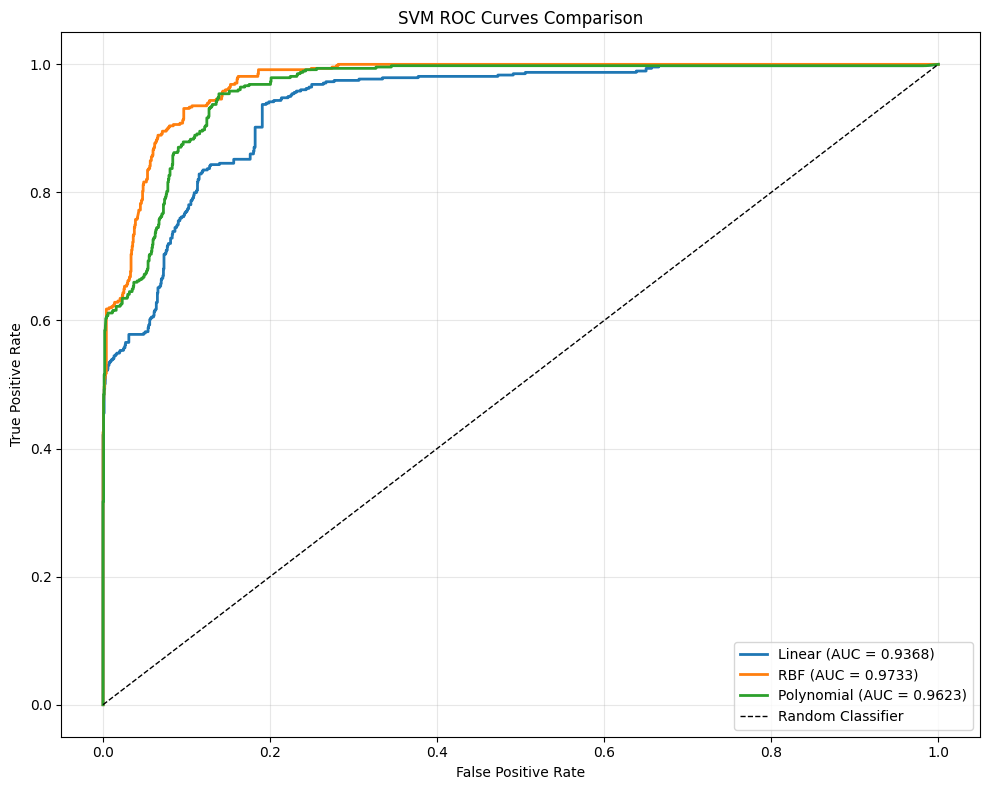


💡 Interpreting ROC Curves

📊 What You Should See:
 - Three colored lines: Linear (blue), RBF (orange), Polynomial (green)
 - Diagonal dashed line: Random classifier (AUC = 0.5, worst possible)
 - Curves above diagonal = better than random
 - Curves closer to top-left corner = better performance

🔍 Key Observations:
 - RBF curve is highest (best AUC = 0.9733) → Best at distinguishing classes
 - Polynomial is next (AUC = 0.9623) → Also excellent
 - Linear is lowest here (AUC = 0.9368) → Still excellent
 - All curves are far above diagonal → all three AUCs are above 0.94

💡 How to Read ROC Curves:
 - X-axis (False Positive Rate): Rate of false alarms
 - Y-axis (True Positive Rate): Rate of correctly detected attacks
 - Top-left corner = perfect (100% detection, 0% false alarms)
 - Diagonal line = random guessing (50% detection, 50% false alarms)
 - Higher curve = better at balancing detection vs false alarms

💡 For GDI Cyber Threat Detection:
 - ROC curves show model's ability to detect 

In [22]:
# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_linear, tpr_linear, linewidth=2, label=f'Linear (AUC = {auc_linear:.4f})')
plt.plot(fpr_rbf, tpr_rbf, linewidth=2, label=f'RBF (AUC = {auc_rbf:.4f})')
plt.plot(fpr_poly, tpr_poly, linewidth=2, label=f'Polynomial (AUC = {auc_poly:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curves Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('svm_roc_curves.png', dpi=300, bbox_inches='tight')
print("\n✓ Plot saved as 'svm_roc_curves.png'")
plt.show()

print("\n" + "=" * 60)
print("💡 Interpreting ROC Curves")
print("=" * 60)
print("\n📊 What You Should See:")
print(" - Three colored lines: Linear (blue), RBF (orange), Polynomial (green)")
print(" - Diagonal dashed line: Random classifier (AUC = 0.5, worst possible)")
print(" - Curves above diagonal = better than random")
print(" - Curves closer to top-left corner = better performance")
print("\n🔍 Key Observations:")
auc_ranked = sorted([('Linear', auc_linear), ('RBF', auc_rbf), ('Polynomial', auc_poly)],
                    key=lambda kv: kv[1], reverse=True)
print(f" - {auc_ranked[0][0]} curve is highest (best AUC = {auc_ranked[0][1]:.4f}) → Best at distinguishing classes")
print(f" - {auc_ranked[1][0]} is next (AUC = {auc_ranked[1][1]:.4f}) → Also excellent")
print(f" - {auc_ranked[2][0]} is lowest here (AUC = {auc_ranked[2][1]:.4f}) → Still excellent")
print(f" - All curves are far above diagonal → all three AUCs are above "
      f"{min(auc_linear, auc_rbf, auc_poly):.2f}")
print("\n💡 How to Read ROC Curves:")
print(" - X-axis (False Positive Rate): Rate of false alarms")
print(" - Y-axis (True Positive Rate): Rate of correctly detected attacks")
print(" - Top-left corner = perfect (100% detection, 0% false alarms)")
print(" - Diagonal line = random guessing (50% detection, 50% false alarms)")
print(" - Higher curve = better at balancing detection vs false alarms")
print("\n💡 For GDI Cyber Threat Detection:")
print(" - ROC curves show model's ability to detect attacks while minimizing false alarms")
print(f" - All three kernels achieve excellent performance "
      f"(AUC > {min(auc_linear, auc_rbf, auc_poly):.2f})")
print(" - RBF kernel has slight edge (best AUC) for this cybersecurity dataset")
print(" - In production, choose kernel with best AUC for most reliable threat detection")
print("\n" + "=" * 60)
print("Example 3 Complete! ✓")
print("=" * 60)

## 📚 References

1. Boser, B. E., Guyon, I. M., & Vapnik, V. N. (1992). *A Training Algorithm for Optimal Margin Classifiers*. COLT 1992.
2. Cortes, C., & Vapnik, V. (1995). *Support-Vector Networks*. Machine Learning, 20, 273–297.
3. Domingos, P. (2020). *Every Model Learned by Gradient Descent Is Approximately a Kernel Machine*. <https://arxiv.org/abs/2012.00152>
4. Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*, Chapter 7. Springer.
5. Rezvani, S., Pourpanah, F., Lim, C. P., & Wu, Q. M. J. (2024). *Methods for Class-Imbalanced Learning with Support Vector Machines: A Review and an Empirical Evaluation*. <https://arxiv.org/abs/2406.03398>
6. Erickson, N., Purucker, L., Tschalzev, A., et al. (2025). *TabArena: A Living Benchmark for Machine Learning on Tabular Data*. <https://arxiv.org/abs/2506.16791>
